<a href="https://colab.research.google.com/github/Anishreddy-gith/Anishreddy-gith/blob/main/CHB_MIT_Seizure_final_nb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CHB-MIT Seizure Prediction Pipeline (chb01, chb02, chb03 + chb04 external test)

End-to-end pipeline built around the seven required steps, plus five research-paper
add-ons (external unseen-patient validation, explicit feature listings per top-K,
detailed architecture documentation, preictal temporal feature analysis, and
pickle-based execution saving):

1. Data Loading (seizure files + annotations)
2. Preprocessing (band-pass filter + 2s / 50% overlap segmentation)
3. Feature Extraction (time, frequency, entropy features) — *+ Add-on: explicit top-K feature listing*
4. CNN and CNN-LSTM models with Leave-One-Patient-Out (LOPO) validation — *+ Add-on: full architecture documentation*
5. Results Comparison (accuracy, precision, recall, F1, confusion matrix, AUC) — *+ Add-on: specificity, MCC, ROC/PR curves*
6. Comparison across different numbers of features
7. Prediction Time (training + inference timing)
8. **Add-on: External validation on chb04 — a genuinely unseen 4th patient**, trained on all of chb01-03
9. **Add-on: Preictal feature analysis** — how far before onset features deviate, which
   features warn earliest/longest/fastest, and an estimated prediction window
10. **Add-on: Execution saving** — all feature matrices, trained models, predictions,
    feature importances, and evaluation metrics pickled to Google Drive for reuse

> **Assumptions:** CHB-MIT native sampling rate is 256 Hz. Only EDF files that contain at
> least one seizure (per each patient's `-summary.txt`) are used, for patients **chb01, chb02, chb03**
> (training/LOPO) and **chb04** (external test only, Step 8).


## Setup — Installation & Imports

In [ ]:
# Install required libraries (Colab-safe: quiet install)
!pip install -q mne scipy scikit-learn tensorflow pandas matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 46.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [ ]:
import os, re, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import mne
from scipy.signal import butter, filtfilt, welch
from scipy.stats import skew, kurtosis, entropy

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score,
                              matthews_corrcoef, roc_curve, precision_recall_curve, auc)

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

import matplotlib.pyplot as plt
from IPython.display import display

mne.set_log_level('ERROR')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ---- Global configuration -------------------------------------------------
PATIENTS = ['chb01', 'chb02', 'chb03']
DATASET_PATH = "/content/drive/MyDrive/EEG_Dataset/CHB Dataset/CHB Dataset"

FS = 256                              # CHB-MIT native sampling rate (Hz)
WINDOW_SEC = 2.0                      # segmentation window size (required)
OVERLAP = 0.5                         # 50% overlap (required)
WINDOW_SAMPLES = int(WINDOW_SEC * FS)
STEP_SAMPLES = int(WINDOW_SAMPLES * (1 - OVERLAP))
N_SUBWINDOWS = 4                      # sub-windows per 2s segment (used for CNN-LSTM sequence input)

# ---- Preictal analysis configuration (Step 9) ------------------------------
PREICTAL_WINDOW_CANDIDATES_MIN = [5, 10, 20, 30]   # candidate prediction-window lengths to test/report
MAX_PREICTAL_MINUTES = 30                          # how far before onset to analyze
BASELINE_MINUTES = 10                              # interictal reference period, taken just before that
DEVIATION_Z_THRESH = 2.0                           # |z-score| threshold to flag a feature as "deviating"
SUSTAIN_WINDOWS = 3                                # consecutive windows required to count as sustained onset

# ---- Global stores for trained models (populated during Step 4 / Step 8, used by Step 10's pickle export)
TRAINED_MODELS = {'cnn': [], 'cnn_lstm': []}
TRAINED_MODELS_EXTERNAL = {}

print("Config OK. Window samples:", WINDOW_SAMPLES, "| Step samples:", STEP_SAMPLES)


Config OK. Window samples: 512 | Step samples: 256


In [ ]:
# Mount Google Drive and verify dataset path
from google.colab import drive
drive.mount('/content/drive')

assert os.path.isdir(DATASET_PATH), f"Dataset path not found: {DATASET_PATH}"
print("Dataset path OK:", DATASET_PATH)


Mounted at /content/drive
Dataset path OK: /content/drive/MyDrive/EEG_Dataset/CHB Dataset/CHB Dataset


## Step 1: Data Loading

Parse each patient's `chbXX-summary.txt` to find files that contain seizures and their
start/end annotations. If the corresponding `.edf` recording isn't already on disk, it is
downloaded from the open PhysioNet CHB-MIT archive (only the specific seizure files
needed — not the full patient record). A clean seizure summary table is then built.


In [ ]:
def parse_summary_file(summary_path):
    """
    Parse a CHB-MIT chbXX-summary.txt file.
    Returns dict: {edf_filename: [(seizure_start_sec, seizure_end_sec), ...]}
    Only files with >=1 seizure are included.
    """
    seizures_by_file = {}
    if not os.path.isfile(summary_path):
        print(f"  [WARN] summary file not found: {summary_path}")
        return seizures_by_file

    with open(summary_path, 'r', errors='ignore') as f:
        content = f.read()

    # Split content into per-file blocks
    blocks = re.split(r'(?=File Name:)', content)
    for block in blocks:
        fname_match = re.search(r'File Name:\s*(\S+)', block)
        if not fname_match:
            continue
        fname = fname_match.group(1)

        n_seiz_match = re.search(r'Number of Seizures in File:\s*(\d+)', block)
        n_seiz = int(n_seiz_match.group(1)) if n_seiz_match else 0
        if n_seiz == 0:
            continue

        starts = re.findall(r'Seizure(?:\s*\d*)?\s*Start Time:\s*(\d+)\s*seconds', block)
        ends = re.findall(r'Seizure(?:\s*\d*)?\s*End Time:\s*(\d+)\s*seconds', block)

        intervals = [(int(s), int(e)) for s, e in zip(starts, ends)]
        if intervals:
            seizures_by_file[fname] = intervals

    return seizures_by_file


### Download the seizure EDF recordings

Only the `.edf.seizures` annotation sidecars and `-summary.txt` files were present on
disk — the actual `.edf` signal recordings that contain a seizure are missing. Those are
fetched here directly from the open-access PhysioNet CHB-MIT repository, **only for the
specific seizure files referenced in each patient's summary** (16 files total across
chb01/chb02/chb03). Files already present on disk are skipped.


In [ ]:
PHYSIONET_BASE_URL = "https://physionet.org/files/chbmit/1.0.0"

needed_files = {}
for p in PATIENTS:
    patient_dir = os.path.join(DATASET_PATH, p)
    summary_path = os.path.join(patient_dir, f"{p}-summary.txt")
    seizures_by_file = parse_summary_file(summary_path)
    needed_files[p] = sorted(seizures_by_file.keys())
    print(f"{p}: {len(needed_files[p])} seizure file(s) needed -> {needed_files[p]}")


chb01: 7 seizure file(s) needed -> ['chb01_03.edf', 'chb01_04.edf', 'chb01_15.edf', 'chb01_16.edf', 'chb01_18.edf', 'chb01_21.edf', 'chb01_26.edf']
chb02: 3 seizure file(s) needed -> ['chb02_16+.edf', 'chb02_16.edf', 'chb02_19.edf']
chb03: 7 seizure file(s) needed -> ['chb03_01.edf', 'chb03_02.edf', 'chb03_03.edf', 'chb03_04.edf', 'chb03_34.edf', 'chb03_35.edf', 'chb03_36.edf']


In [ ]:
for p in PATIENTS:
    patient_dir = os.path.join(DATASET_PATH, p)
    os.makedirs(patient_dir, exist_ok=True)
    for fname in needed_files[p]:
        dest = os.path.join(patient_dir, fname)
        if os.path.isfile(dest) and os.path.getsize(dest) > 1_000_000:
            print(f"  [SKIP] already present: {p}/{fname} ({os.path.getsize(dest)/1e6:.1f} MB)")
            continue
        url = f"{PHYSIONET_BASE_URL}/{p}/{fname}"
        print(f"  Downloading {p}/{fname} ...")
        exit_code = os.system(f'wget -q -O "{dest}" "{url}"')
        if exit_code != 0 or not os.path.isfile(dest) or os.path.getsize(dest) < 1_000_000:
            print(f"    [WARN] Download failed or file too small for {fname} (url: {url})")
        else:
            print(f"    -> {os.path.getsize(dest)/1e6:.1f} MB")

print("\nDownload pass complete.")


  [SKIP] already present: chb01/chb01_03.edf (42.4 MB)
  [SKIP] already present: chb01/chb01_04.edf (42.4 MB)
  [SKIP] already present: chb01/chb01_15.edf (42.4 MB)
  [SKIP] already present: chb01/chb01_16.edf (42.4 MB)
  [SKIP] already present: chb01/chb01_18.edf (42.4 MB)
  [SKIP] already present: chb01/chb01_21.edf (42.4 MB)
  [SKIP] already present: chb01/chb01_26.edf (27.4 MB)
  [SKIP] already present: chb02/chb02_16+.edf (42.4 MB)
  [SKIP] already present: chb02/chb02_16.edf (11.3 MB)
  [SKIP] already present: chb02/chb02_19.edf (42.4 MB)
  [SKIP] already present: chb03/chb03_01.edf (42.4 MB)
  [SKIP] already present: chb03/chb03_02.edf (42.4 MB)
  [SKIP] already present: chb03/chb03_03.edf (42.4 MB)
  [SKIP] already present: chb03/chb03_04.edf (42.4 MB)
  [SKIP] already present: chb03/chb03_34.edf (42.4 MB)
  [SKIP] already present: chb03/chb03_35.edf (42.4 MB)
  [SKIP] already present: chb03/chb03_36.edf (42.4 MB)

Download pass complete.


In [ ]:
def get_patient_seizure_info(patient_id, dataset_path):
    """Build a dataframe of seizure events for a single patient (seizure files only)."""
    patient_dir = os.path.join(dataset_path, patient_id)
    summary_path = os.path.join(patient_dir, f"{patient_id}-summary.txt")
    seizures_by_file = parse_summary_file(summary_path)

    rows = []
    for fname, intervals in seizures_by_file.items():
        edf_path = os.path.join(patient_dir, fname)
        if not os.path.isfile(edf_path):
            print(f"  [WARN] EDF listed in summary but not found on disk: {edf_path}")
            continue
        for i, (start, end) in enumerate(intervals, start=1):
            rows.append({
                'patient': patient_id,
                'file': fname,
                'edf_path': edf_path,
                'seizure_idx': i,
                'start_sec': start,
                'end_sec': end,
                'duration_sec': end - start
            })
    return pd.DataFrame(rows)

seizure_dfs = []
for p in PATIENTS:
    df_p = get_patient_seizure_info(p, DATASET_PATH)
    seizure_dfs.append(df_p)

seizure_df = pd.concat(seizure_dfs, ignore_index=True)
print("Total seizure annotation records loaded:", len(seizure_df))
seizure_df.head(10)


Total seizure annotation records loaded: 17


,patient,file,edf_path,seizure_idx,start_sec,end_sec,duration_sec
0,chb01,chb01_03.edf,/content/drive/MyDrive/EEG_Dataset/CHB Dataset...,1,2996,3036,40
1,chb01,chb01_04.edf,/content/drive/MyDrive/EEG_Dataset/CHB Dataset...,1,1467,1494,27
2,chb01,chb01_15.edf,/content/drive/MyDrive/EEG_Dataset/CHB Dataset...,1,1732,1772,40
3,chb01,chb01_16.edf,/content/drive/MyDrive/EEG_Dataset/CHB Dataset...,1,1015,1066,51
4,chb01,chb01_18.edf,/content/drive/MyDrive/EEG_Dataset/CHB Dataset...,1,1720,1810,90
5,chb01,chb01_21.edf,/content/drive/MyDrive/EEG_Dataset/CHB Dataset...,1,327,420,93
6,chb01,chb01_26.edf,/content/drive/MyDrive/EEG_Dataset/CHB Dataset...,1,1862,1963,101
7,chb02,chb02_16.edf,/content/drive/MyDrive/EEG_Dataset/CHB Dataset...,1,130,212,82
8,chb02,chb02_16+.edf,/content/drive/MyDrive/EEG_Dataset/CHB Dataset...,1,2972,3053,81
9,chb02,chb02_19.edf,/content/drive/MyDrive/EEG_Dataset/CHB Dataset...,1,3369,3378,9


In [ ]:
# Clean seizure summary tables
summary_rows = []
for p in PATIENTS:
    sub = seizure_df[seizure_df['patient'] == p]
    n_events = len(sub)
    total_dur = sub['duration_sec'].sum()
    summary_rows.append({
        'Patient': p,
        'Num Seizure Events': n_events,
        'Total Seizure Duration (s)': total_dur,
        'Avg Seizure Duration (s)': round(sub['duration_sec'].mean(), 1) if n_events else 0,
        'Num Seizure Files': sub['file'].nunique()
    })

summary_table = pd.DataFrame(summary_rows)
print("=== Seizure Summary (per patient) ===")
display(summary_table)

print("\n=== Per-Seizure Durations ===")
display(seizure_df[['patient', 'file', 'seizure_idx', 'start_sec', 'end_sec', 'duration_sec']])


=== Seizure Summary (per patient) ===


,Patient,Num Seizure Events,Total Seizure Duration (s),Avg Seizure Duration (s),Num Seizure Files
0,chb01,7,442,63.1,7
1,chb02,3,172,57.3,3
2,chb03,7,402,57.4,7



=== Per-Seizure Durations ===


,patient,file,seizure_idx,start_sec,end_sec,duration_sec
0,chb01,chb01_03.edf,1,2996,3036,40
1,chb01,chb01_04.edf,1,1467,1494,27
2,chb01,chb01_15.edf,1,1732,1772,40
3,chb01,chb01_16.edf,1,1015,1066,51
4,chb01,chb01_18.edf,1,1720,1810,90
5,chb01,chb01_21.edf,1,327,420,93
6,chb01,chb01_26.edf,1,1862,1963,101
7,chb02,chb02_16.edf,1,130,212,82
8,chb02,chb02_16+.edf,1,2972,3053,81
9,chb02,chb02_19.edf,1,3369,3378,9


## Step 2: Preprocessing

Band-pass filter (0.5–40 Hz, standard EEG clinical band) followed by segmentation into
2-second windows with 50% overlap. Labels are assigned by overlap with the annotated
seizure interval(s). The pipeline is a set of reusable functions applied identically to
all three patients.


In [ ]:
def bandpass_filter(data, low=0.5, high=40.0, fs=FS, order=4):
    """
    Zero-phase Butterworth band-pass filter, suitable for scalp EEG.
    data shape: (n_channels, n_samples)
    """
    nyq = fs / 2.0
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    return filtfilt(b, a, data, axis=-1)


def segment_recording(raw_data, fs, seizure_intervals, window_sec=WINDOW_SEC, overlap=OVERLAP):
    """
    Segment a filtered recording into fixed windows with overlap and label each window.

    raw_data: (n_channels, n_samples) filtered EEG
    seizure_intervals: list of (start_sec, end_sec)
    A segment is labeled 1 (seizure) if it overlaps >= 50% of its own duration with any
    annotated seizure interval, else 0.

    Returns: segments (n_segments, n_channels, window_samples), labels (n_segments,)
    """
    win = int(window_sec * fs)
    step = int(win * (1 - overlap))
    n_samples = raw_data.shape[1]

    segments, labels = [], []
    start = 0
    while start + win <= n_samples:
        seg = raw_data[:, start:start + win]
        seg_start_sec = start / fs
        seg_end_sec = (start + win) / fs

        label = 0
        for (s_start, s_end) in seizure_intervals:
            overlap_start = max(seg_start_sec, s_start)
            overlap_end = min(seg_end_sec, s_end)
            overlap_len = max(0.0, overlap_end - overlap_start)
            if overlap_len >= 0.5 * window_sec:
                label = 1
                break

        segments.append(seg)
        labels.append(label)
        start += step

    return np.array(segments, dtype=np.float32), np.array(labels, dtype=np.int64)


In [ ]:
def load_and_segment_patient(patient_id, dataset_path, seizure_df):
    """
    Loads ONLY the seizure-containing EDF files for a patient, band-pass filters them,
    and segments them into 2s / 50%-overlap windows with seizure/non-seizure labels.

    Returns: segments (N, C, T), labels (N,), channel_names (list)
    """
    pat_events = seizure_df[seizure_df['patient'] == patient_id]
    files = pat_events[['file', 'edf_path']].drop_duplicates()

    all_segments, all_labels = [], []
    common_channels = None

    for _, row in files.iterrows():
        edf_path = row['edf_path']
        fname = row['file']
        intervals = list(zip(
            pat_events[pat_events['file'] == fname]['start_sec'],
            pat_events[pat_events['file'] == fname]['end_sec']
        ))

        try:
            raw = mne.io.read_raw_edf(edf_path, preload=True, verbose='ERROR')
        except Exception as e:
            print(f"  [WARN] Could not read {edf_path}: {e}")
            continue

        if common_channels is None:
            common_channels = raw.ch_names
        else:
            common_channels = [ch for ch in common_channels if ch in raw.ch_names] or common_channels

        raw.pick(common_channels)
        fs = int(round(raw.info['sfreq']))
        data = raw.get_data()  # (n_channels, n_samples)

        data = bandpass_filter(data, fs=fs)
        segs, labs = segment_recording(data, fs, intervals)

        all_segments.append(segs)
        all_labels.append(labs)
        print(f"  {patient_id}/{fname}: {segs.shape[0]} segments "
              f"({int(labs.sum())} seizure, {int(len(labs) - labs.sum())} non-seizure)")

    if not all_segments:
        return np.empty((0,)), np.empty((0,)), []

    # Guard against small channel-count mismatches across files by truncating to the
    # minimum common channel count observed.
    min_ch = min(s.shape[1] for s in all_segments)
    all_segments = [s[:, :min_ch, :] for s in all_segments]

    segments = np.concatenate(all_segments, axis=0)
    labels = np.concatenate(all_labels, axis=0)
    return segments, labels, common_channels[:min_ch]


patient_data = {}
print("Segmenting patient recordings (2s window, 50% overlap)...")
for p in PATIENTS:
    print(f"\nPatient {p}:")
    segs, labs, chans = load_and_segment_patient(p, DATASET_PATH, seizure_df)
    patient_data[p] = {'segments': segs, 'labels': labs, 'channels': chans}


Segmenting patient recordings (2s window, 50% overlap)...

Patient chb01:
  chb01/chb01_03.edf: 3599 segments (41 seizure, 3558 non-seizure)
  chb01/chb01_04.edf: 3599 segments (28 seizure, 3571 non-seizure)
  chb01/chb01_15.edf: 3599 segments (41 seizure, 3558 non-seizure)
  chb01/chb01_16.edf: 3599 segments (52 seizure, 3547 non-seizure)
  chb01/chb01_18.edf: 3599 segments (91 seizure, 3508 non-seizure)
  chb01/chb01_21.edf: 3599 segments (94 seizure, 3505 non-seizure)
  chb01/chb01_26.edf: 2324 segments (102 seizure, 2222 non-seizure)

Patient chb02:
  chb02/chb02_16.edf: 958 segments (83 seizure, 875 non-seizure)
  chb02/chb02_16+.edf: 3599 segments (82 seizure, 3517 non-seizure)
  chb02/chb02_19.edf: 3599 segments (10 seizure, 3589 non-seizure)

Patient chb03:
  chb03/chb03_01.edf: 3599 segments (53 seizure, 3546 non-seizure)
  chb03/chb03_02.edf: 3599 segments (66 seizure, 3533 non-seizure)
  chb03/chb03_03.edf: 3599 segments (70 seizure, 3529 non-seizure)
  chb03/chb03_04.edf: 3

In [ ]:
# Segment counts per patient after preprocessing
seg_summary = pd.DataFrame([
    {
        'Patient': p,
        'Total Segments': len(patient_data[p]['labels']),
        'Seizure Segments': int(patient_data[p]['labels'].sum()),
        'Non-Seizure Segments': int(len(patient_data[p]['labels']) - patient_data[p]['labels'].sum()),
        'Channels Used': len(patient_data[p]['channels'])
    }
    for p in PATIENTS
])
print("=== Segments per Patient (2s window / 50% overlap) ===")
display(seg_summary)


=== Segments per Patient (2s window / 50% overlap) ===


,Patient,Total Segments,Seizure Segments,Non-Seizure Segments,Channels Used
0,chb01,23918,449,23469,23
1,chb02,8156,175,7981,23
2,chb03,25193,409,24784,23


## Step 3: Feature Extraction

For each 2-second segment: average across channels to get one representative signal,
split it into 4 sub-windows (0.5s each), and compute time-domain, frequency-band, and
entropy features per sub-window.

* **`seq_X`** — shape `(N, sub-windows, n_features)` → sequence input for the **CNN-LSTM**.
* **`flat_X`** — the same features flattened → vector input for the **CNN** (and for
  Random-Forest based feature-importance analysis).


In [ ]:
BANDS = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta':  (13, 30),
    'gamma': (30, 45),
}

def band_power(sig, fs, band):
    freqs, psd = welch(sig, fs=fs, nperseg=min(len(sig), 128))
    idx = np.logical_and(freqs >= band[0], freqs <= band[1])
    return float(np.trapz(psd[idx], freqs[idx])) if idx.any() else 0.0

def line_length(sig):
    return float(np.sum(np.abs(np.diff(sig))))

def signal_entropy(sig, bins=16):
    hist, _ = np.histogram(sig, bins=bins, density=True)
    hist = hist[hist > 0]
    return float(entropy(hist)) if len(hist) else 0.0

def extract_subwindow_features(sig, fs):
    """sig: 1D array (channel-averaged signal for one sub-window). Returns dict of scalars."""
    feats = {
        'mean': float(np.mean(sig)),
        'std': float(np.std(sig)),
        'skew': float(skew(sig)),
        'kurtosis': float(kurtosis(sig)),
        'line_length': line_length(sig),
        'zero_crossings': float(np.sum(np.diff(np.sign(sig)) != 0)),
        'entropy': signal_entropy(sig),
    }
    for band_name, band_range in BANDS.items():
        feats[f'{band_name}_power'] = band_power(sig, fs, band_range)
    return feats


In [ ]:
def build_features_for_segment(segment, fs, n_subwindows=N_SUBWINDOWS):
    """
    segment: (n_channels, window_samples)
    Returns:
      seq_features  : (n_subwindows, n_feats_per_sw)  -- for CNN-LSTM
      flat_features : (n_subwindows * n_feats_per_sw,) -- for CNN / Random Forest
      feature_names : list[str] aligned with flat_features
    """
    avg_signal = segment.mean(axis=0)
    sub_len = len(avg_signal) // n_subwindows

    seq_feats, feature_names, base_names = [], [], None
    for i in range(n_subwindows):
        chunk = avg_signal[i * sub_len:(i + 1) * sub_len]
        feat_dict = extract_subwindow_features(chunk, fs)
        seq_feats.append(list(feat_dict.values()))
        if base_names is None:
            base_names = list(feat_dict.keys())
        feature_names.extend([f"{name}_sw{i}" for name in base_names])

    seq_features = np.array(seq_feats, dtype=np.float32)
    flat_features = seq_features.flatten()
    return seq_features, flat_features, feature_names


def build_feature_dataset(segments, fs=FS):
    seq_list, flat_list, feature_names = [], [], None
    for seg in segments:
        seq_f, flat_f, names = build_features_for_segment(seg, fs)
        seq_list.append(seq_f)
        flat_list.append(flat_f)
        feature_names = names
    return np.array(seq_list, dtype=np.float32), np.array(flat_list, dtype=np.float32), feature_names


print("Extracting features for each patient (this may take a few minutes)...")
for p in PATIENTS:
    segs = patient_data[p]['segments']
    seq_X, flat_X, feat_names = build_feature_dataset(segs)
    patient_data[p]['seq_X'] = seq_X          # (N, subwindows, n_feats) -> CNN-LSTM
    patient_data[p]['flat_X'] = flat_X        # (N, subwindows*n_feats)  -> CNN / RF
    patient_data[p]['feature_names'] = feat_names
    print(f"  {p}: seq_X {seq_X.shape}, flat_X {flat_X.shape}")


Extracting features for each patient (this may take a few minutes)...
  chb01: seq_X (23918, 4, 12), flat_X (23918, 48)
  chb02: seq_X (8156, 4, 12), flat_X (8156, 48)
  chb03: seq_X (25193, 4, 12), flat_X (25193, 48)


=== Top 15 Predominant Features for Seizure Prediction ===


,feature,importance
0,std_sw2,0.098234
1,line_length_sw3,0.095566
2,line_length_sw2,0.093554
3,line_length_sw1,0.078895
4,line_length_sw0,0.073462
5,std_sw0,0.061757
6,std_sw3,0.049430
7,theta_power_sw0,0.042019
8,std_sw1,0.041411
9,theta_power_sw3,0.038889


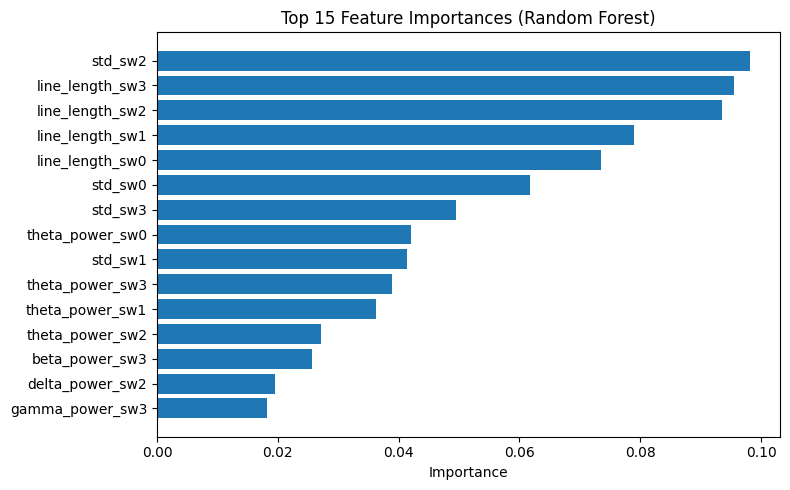

In [ ]:
# Feature importance (Random Forest) to find the predominant features
X_all = np.concatenate([patient_data[p]['flat_X'] for p in PATIENTS], axis=0)
y_all = np.concatenate([patient_data[p]['labels'] for p in PATIENTS], axis=0)
feature_names = patient_data[PATIENTS[0]]['feature_names']

# Base feature names (the 12 real features computed per sub-window, before the
# subwindow suffix was appended). seq_X's last axis is indexed by THESE, while
# flat_X / feature_names covers all 48 (12 base features x 4 sub-windows).
BASE_FEATURE_NAMES = list(dict.fromkeys([f.rsplit('_sw', 1)[0] for f in feature_names]))

scaler_fi = StandardScaler()
X_all_scaled = scaler_fi.fit_transform(X_all)

rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED,
                             class_weight='balanced', n_jobs=-1)
rf.fit(X_all_scaled, y_all)

importances = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("=== Top 15 Predominant Features for Seizure Prediction ===")
display(importances.head(15))

plt.figure(figsize=(8, 5))
plt.barh(importances['feature'].head(15)[::-1], importances['importance'].head(15)[::-1])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

TOP_FEATURE_ORDER = importances['feature'].tolist()   # used later in Step 6


### Add-on: Feature Sets Used at Each Feature Count (10 / 20 / 30 / 48)

Explicit listing of which named features fall into each top-K set evaluated in Step 6,
for direct reporting in a paper's methodology / results table.


In [ ]:
ADDON_FEATURE_COUNTS = [10, 20, 30, len(feature_names)]

feature_rank_table = importances.copy()
feature_rank_table.insert(0, 'rank', range(1, len(feature_rank_table) + 1))
feature_rank_table['importance'] = feature_rank_table['importance'].round(4)
for k in ADDON_FEATURE_COUNTS:
    col_name = f'In Top {k}' if k < len(feature_names) else f'In Full Set ({k})'
    feature_rank_table[col_name] = feature_rank_table['rank'] <= k

print("=== Full Ranked Feature Table with Top-K Membership ===")
display(feature_rank_table)

print("\n=== Feature Lists for Each K (for direct reporting in the paper) ===")
for k in ADDON_FEATURE_COUNTS:
    label = f"Top {k}" if k < len(feature_names) else f"All {k} (full feature set)"
    flist = TOP_FEATURE_ORDER[:k]
    print(f"\n{label} features ({len(flist)}):")
    for i, f in enumerate(flist, start=1):
        print(f"  {i:2d}. {f}")


=== Full Ranked Feature Table with Top-K Membership ===


,rank,feature,importance,In Top 10,In Top 20,In Top 30,In Full Set (48)
0,1,std_sw2,0.0982,True,True,True,True
1,2,line_length_sw3,0.0956,True,True,True,True
2,3,line_length_sw2,0.0936,True,True,True,True
3,4,line_length_sw1,0.0789,True,True,True,True
4,5,line_length_sw0,0.0735,True,True,True,True
5,6,std_sw0,0.0618,True,True,True,True
6,7,std_sw3,0.0494,True,True,True,True
7,8,theta_power_sw0,0.0420,True,True,True,True
8,9,std_sw1,0.0414,True,True,True,True
9,10,theta_power_sw3,0.0389,True,True,True,True



=== Feature Lists for Each K (for direct reporting in the paper) ===

Top 10 features (10):
   1. std_sw2
   2. line_length_sw3
   3. line_length_sw2
   4. line_length_sw1
   5. line_length_sw0
   6. std_sw0
   7. std_sw3
   8. theta_power_sw0
   9. std_sw1
  10. theta_power_sw3

Top 20 features (20):
   1. std_sw2
   2. line_length_sw3
   3. line_length_sw2
   4. line_length_sw1
   5. line_length_sw0
   6. std_sw0
   7. std_sw3
   8. theta_power_sw0
   9. std_sw1
  10. theta_power_sw3
  11. theta_power_sw1
  12. theta_power_sw2
  13. beta_power_sw3
  14. delta_power_sw2
  15. gamma_power_sw3
  16. gamma_power_sw1
  17. delta_power_sw0
  18. beta_power_sw1
  19. beta_power_sw2
  20. delta_power_sw3

Top 30 features (30):
   1. std_sw2
   2. line_length_sw3
   3. line_length_sw2
   4. line_length_sw1
   5. line_length_sw0
   6. std_sw0
   7. std_sw3
   8. theta_power_sw0
   9. std_sw1
  10. theta_power_sw3
  11. theta_power_sw1
  12. theta_power_sw2
  13. beta_power_sw3
  14. delta_pow

## Step 4: CNN and CNN-LSTM Models with LOPO Validation

* **CNN** — 1D convolutional network over the flattened feature vector.
* **CNN-LSTM** — a small per-timestep Conv1D feature extractor (`TimeDistributed`)
  followed by an LSTM over the 4 sub-window timesteps.
* **LOPO (Leave-One-Patient-Out)**: train on 2 patients, test on the remaining one,
  repeated for all 3 patients — the split is strictly patient-wise (no random mixing).
* Regularization: `BatchNormalization`, `Dropout`, and `EarlyStopping` (on validation loss).


In [ ]:
def build_cnn(input_dim):
    """1D CNN operating on the flattened feature vector."""
    model = models.Sequential([
        layers.Input(shape=(input_dim, 1)),
        layers.Conv1D(32, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),
        layers.Dropout(0.3),
        layers.Conv1D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ], name='CNN')
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


def build_cnn_lstm(n_timesteps, n_features):
    """Per-timestep CNN feature extractor (TimeDistributed) + LSTM over sub-windows."""
    model = models.Sequential([
        layers.Input(shape=(n_timesteps, n_features, 1)),
        layers.TimeDistributed(layers.Conv1D(16, 3, padding='same', activation='relu')),
        layers.TimeDistributed(layers.BatchNormalization()),
        layers.TimeDistributed(layers.GlobalAveragePooling1D()),
        layers.LSTM(32, return_sequences=False, dropout=0.3, recurrent_dropout=0.2),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ], name='CNN_LSTM')
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


### Add-on: Detailed Architecture Documentation (for the Methodology Section)

Full layer-by-layer specification of both networks, printed directly from Keras so the
exact output shapes and parameter counts are unambiguous and reproducible for a paper.


In [ ]:
sample_cnn = build_cnn(len(feature_names))
print("=" * 78)
print("CNN — Full Architecture Summary  (input: flattened 48-d feature vector)")
print("=" * 78)
sample_cnn.summary()

sample_cnn_lstm = build_cnn_lstm(N_SUBWINDOWS, len(BASE_FEATURE_NAMES))
print("\n" + "=" * 78)
print("CNN-LSTM — Full Architecture Summary  (input: 4 timesteps x 12 features)")
print("=" * 78)
sample_cnn_lstm.summary()


def _count_params(model):
    trainable = int(sum(np.prod(v.shape) for v in model.trainable_weights))
    non_trainable = int(sum(np.prod(v.shape) for v in model.non_trainable_weights))
    return trainable, non_trainable

cnn_trainable, cnn_nontrainable = _count_params(sample_cnn)
lstm_trainable, lstm_nontrainable = _count_params(sample_cnn_lstm)

complexity_df = pd.DataFrame([
    {'Model': 'CNN', 'Trainable Params': cnn_trainable, 'Non-trainable Params': cnn_nontrainable,
     'Total Params': cnn_trainable + cnn_nontrainable,
     'Approx. Size (KB, float32)': round((cnn_trainable + cnn_nontrainable) * 4 / 1024, 1)},
    {'Model': 'CNN-LSTM', 'Trainable Params': lstm_trainable, 'Non-trainable Params': lstm_nontrainable,
     'Total Params': lstm_trainable + lstm_nontrainable,
     'Approx. Size (KB, float32)': round((lstm_trainable + lstm_nontrainable) * 4 / 1024, 1)},
])
print("\n=== Model Complexity Comparison ===")
display(complexity_df)


CNN — Full Architecture Summary  (input: flattened 48-d feature vector)


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 48, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 24, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,641 (33.75 KB)

...

 Total params: 7,489 (29.25 KB)

 Trainable params: 7,457 (29.13 KB)

 Non-trainable params: 32 (128.00 B)


=== Model Complexity Comparison ===


,Model,Trainable Params,Non-trainable Params,Total Params,"Approx. Size (KB, float32)"
0,CNN,8641,192,8833,34.5
1,CNN-LSTM,7457,32,7489,29.3


**CNN architecture (methods-section description).** The network takes the 48-dimensional
flattened feature vector (12 hand-crafted features x 4 sub-windows) as a single-channel
1D sequence. A first `Conv1D` layer (32 filters, kernel size 3, `same` padding, ReLU)
learns local filters over adjacent feature positions, followed by `BatchNormalization`
for training stability, `MaxPooling1D` (pool size 2) for downsampling, and `Dropout`
(rate 0.3) for regularization. A second `Conv1D` layer (64 filters, kernel size 3, ReLU)
increases representational capacity, followed again by `BatchNormalization`. A
`GlobalAveragePooling1D` layer then collapses the feature-map dimension (more parameter-
efficient and less overfitting-prone than `Flatten` + `Dense`), followed by `Dropout`
(0.3), a `Dense(32, relu)` layer, and a final `Dense(1, sigmoid)` output for binary
seizure/non-seizure classification.

**CNN-LSTM architecture (methods-section description).** The network takes a
`(4 timesteps, 12 features)` sequence — one feature vector per 0.5s sub-window within
the 2s segment — preserving short-term temporal structure that the flattened CNN input
discards. A `TimeDistributed(Conv1D(16, kernel_size=3, ReLU))` layer applies the same
1D convolution independently to every timestep's 12-length feature vector, followed by
`TimeDistributed(BatchNormalization)` and `TimeDistributed(GlobalAveragePooling1D)` to
produce one compact embedding per timestep. An `LSTM(32)` layer then models the temporal
dependency across the 4 embeddings (`dropout=0.3`, `recurrent_dropout=0.2` for
regularization), followed by `Dense(32, relu)`, `Dropout(0.3)`, and a final
`Dense(1, sigmoid)` output.

**Shared training configuration.** Both models: Adam optimizer, binary cross-entropy
loss, batch size 64, up to 30 epochs (20 for the Step 6 feature-count sweep) with
`EarlyStopping` (`monitor='val_loss'`, `patience=5`, `restore_best_weights=True`) on a
15% validation split carved from the training folds, and inverse-frequency class
weighting to counter the seizure/non-seizure class imbalance. Under LOPO, both models
are trained from randomly-initialized weights on 2 patients and evaluated on the fully
held-out third.


In [ ]:
def run_lopo(model_type='cnn', feature_names_subset=None, epochs=30, batch_size=64, verbose=0,
             store_model=True):
    """
    Generic Leave-One-Patient-Out evaluator.
    model_type: 'cnn' or 'cnn_lstm'
    feature_names_subset: optional list restricting which features to use (Step 6)
    store_model: if True, keep the trained Keras model in TRAINED_MODELS for later pickle export
                 (Step 10). Set False for large sweeps (e.g. Step 6) to avoid bloating memory.
    Returns: list of per-fold metric/timing dicts.
    """
    results = []

    # flat_X (CNN) is indexed over all 48 (12 base features x 4 sub-windows) flattened
    # entries. seq_X (CNN-LSTM) keeps sub-windows and features as separate axes, so its
    # last axis only spans the 12 BASE feature names -- these need separate index sets.
    if feature_names_subset is not None:
        col_idx = [feature_names.index(f) for f in feature_names_subset]
        base_subset = list(dict.fromkeys([f.rsplit('_sw', 1)[0] for f in feature_names_subset]))
        col_idx_seq = [BASE_FEATURE_NAMES.index(b) for b in base_subset]
    else:
        col_idx = list(range(len(feature_names)))
        col_idx_seq = list(range(len(BASE_FEATURE_NAMES)))

    for test_p in PATIENTS:
        train_ps = [p for p in PATIENTS if p != test_p]

        if model_type == 'cnn':
            X_train = np.concatenate([patient_data[p]['flat_X'][:, col_idx] for p in train_ps], axis=0)
            X_test = patient_data[test_p]['flat_X'][:, col_idx]
        else:
            X_train = np.concatenate([patient_data[p]['seq_X'][:, :, col_idx_seq] for p in train_ps], axis=0)
            X_test = patient_data[test_p]['seq_X'][:, :, col_idx_seq]

        y_train = np.concatenate([patient_data[p]['labels'] for p in train_ps], axis=0)
        y_test = patient_data[test_p]['labels']

        if model_type == 'cnn':
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
            X_train = X_train[..., np.newaxis]
            X_test = X_test[..., np.newaxis]
            model = build_cnn(X_train.shape[1])
        else:
            n_t, n_f = X_train.shape[1], X_train.shape[2]
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train.reshape(-1, n_f)).reshape(-1, n_t, n_f)
            X_test = scaler.transform(X_test.reshape(-1, n_f)).reshape(-1, n_t, n_f)
            X_train = X_train[..., np.newaxis]
            X_test = X_test[..., np.newaxis]
            model = build_cnn_lstm(n_t, n_f)

        es = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        pos = max(1, int(y_train.sum()))
        neg = max(1, len(y_train) - pos)
        class_weight = {0: 1.0, 1: neg / pos}

        t0 = time.time()
        model.fit(X_train, y_train, validation_split=0.15, epochs=epochs,
                  batch_size=batch_size, callbacks=[es], verbose=verbose,
                  class_weight=class_weight)
        train_time = time.time() - t0

        if store_model:
            TRAINED_MODELS.setdefault(model_type, []).append({'test_patient': test_p, 'model': model})

        t1 = time.time()
        y_prob = model.predict(X_test, verbose=0).ravel()
        infer_time_total = time.time() - t1
        infer_time_per_sample = infer_time_total / max(1, len(X_test))

        y_pred = (y_prob >= 0.5).astype(int)
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        mcc = matthews_corrcoef(y_test, y_pred) if len(np.unique(y_test)) > 1 else np.nan

        metrics_dict = {
            'model': model_type,
            'test_patient': test_p,
            'n_features': len(col_idx),
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1': f1_score(y_test, y_pred, zero_division=0),
            'specificity': specificity,
            'mcc': mcc,
            'auc': roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else np.nan,
            'confusion_matrix': cm.tolist(),
            'train_time_sec': train_time,
            'infer_time_per_sample_sec': infer_time_per_sample,
            'n_train': len(y_train),
            'n_test': len(y_test),
            'y_test': y_test.tolist(),
            'y_prob': y_prob.tolist(),
        }
        results.append(metrics_dict)
        auc_str = f"{metrics_dict['auc']:.3f}" if not np.isnan(metrics_dict['auc']) else "N/A"
        print(f"[{model_type.upper()}] Test={test_p} | Acc={metrics_dict['accuracy']:.3f} "
              f"F1={metrics_dict['f1']:.3f} AUC={auc_str} "
              f"TrainTime={train_time:.1f}s InferTime/seg={infer_time_per_sample*1000:.3f}ms")

    return results


In [ ]:
print("=== LOPO Evaluation: CNN (all features) ===")
cnn_results = run_lopo(model_type='cnn', epochs=30)

print("\n=== LOPO Evaluation: CNN-LSTM (all features) ===")
cnn_lstm_results = run_lopo(model_type='cnn_lstm', epochs=30)


=== LOPO Evaluation: CNN (all features) ===
[CNN] Test=chb01 | Acc=0.982 F1=0.622 AUC=0.981 TrainTime=37.8s InferTime/seg=0.132ms
[CNN] Test=chb02 | Acc=0.865 F1=0.236 AUC=0.981 TrainTime=142.3s InferTime/seg=0.108ms
[CNN] Test=chb03 | Acc=0.981 F1=0.544 AUC=0.953 TrainTime=36.4s InferTime/seg=0.085ms

=== LOPO Evaluation: CNN-LSTM (all features) ===
[CNN_LSTM] Test=chb01 | Acc=0.951 F1=0.404 AUC=0.980 TrainTime=108.1s InferTime/seg=0.218ms
[CNN_LSTM] Test=chb02 | Acc=0.603 F1=0.096 AUC=0.966 TrainTime=163.1s InferTime/seg=0.210ms
[CNN_LSTM] Test=chb03 | Acc=0.965 F1=0.438 AUC=0.965 TrainTime=106.1s InferTime/seg=0.206ms


## Step 5: Results Comparison

In [ ]:
def results_to_df(results):
    return pd.DataFrame([{
        'Test Patient': r['test_patient'],
        'Accuracy': round(r['accuracy'], 3),
        'Precision': round(r['precision'], 3),
        'Recall': round(r['recall'], 3),
        'F1-score': round(r['f1'], 3),
        'AUC': round(r['auc'], 3) if not np.isnan(r['auc']) else 'N/A',
        'Confusion Matrix': r['confusion_matrix']
    } for r in results])

cnn_df = results_to_df(cnn_results)
cnn_lstm_df = results_to_df(cnn_lstm_results)

print("=== CNN — Per-Fold LOPO Results ===")
display(cnn_df)

print("\n=== CNN-LSTM — Per-Fold LOPO Results ===")
display(cnn_lstm_df)


def avg_metrics(results, name):
    return {
        'Model': name,
        'Avg Accuracy': np.mean([r['accuracy'] for r in results]),
        'Avg Precision': np.mean([r['precision'] for r in results]),
        'Avg Recall': np.mean([r['recall'] for r in results]),
        'Avg F1-score': np.mean([r['f1'] for r in results]),
        'Avg AUC': np.nanmean([r['auc'] for r in results]),
    }

comparison_df = pd.DataFrame([
    avg_metrics(cnn_results, 'CNN'),
    avg_metrics(cnn_lstm_results, 'CNN-LSTM'),
]).round(3)

print("\n=== Model Comparison (Averaged over LOPO folds) ===")
display(comparison_df)


=== CNN — Per-Fold LOPO Results ===


,Test Patient,Accuracy,Precision,Recall,F1-score,AUC,Confusion Matrix
0,chb01,0.982,0.523,0.768,0.622,0.981,"[[23154, 315], [104, 345]]"
1,chb02,0.865,0.134,0.971,0.236,0.981,"[[6885, 1096], [5, 170]]"
2,chb03,0.981,0.445,0.699,0.544,0.953,"[[24428, 356], [123, 286]]"



=== CNN-LSTM — Per-Fold LOPO Results ===


,Test Patient,Accuracy,Precision,Recall,F1-score,AUC,Confusion Matrix
0,chb01,0.951,0.262,0.884,0.404,0.980,"[[22352, 1117], [52, 397]]"
1,chb02,0.603,0.051,0.983,0.096,0.966,"[[4748, 3233], [3, 172]]"
2,chb03,0.965,0.295,0.851,0.438,0.965,"[[23952, 832], [61, 348]]"



=== Model Comparison (Averaged over LOPO folds) ===


,Model,Avg Accuracy,Avg Precision,Avg Recall,Avg F1-score,Avg AUC
0,CNN,0.943,0.367,0.813,0.467,0.972
1,CNN-LSTM,0.840,0.203,0.906,0.313,0.970


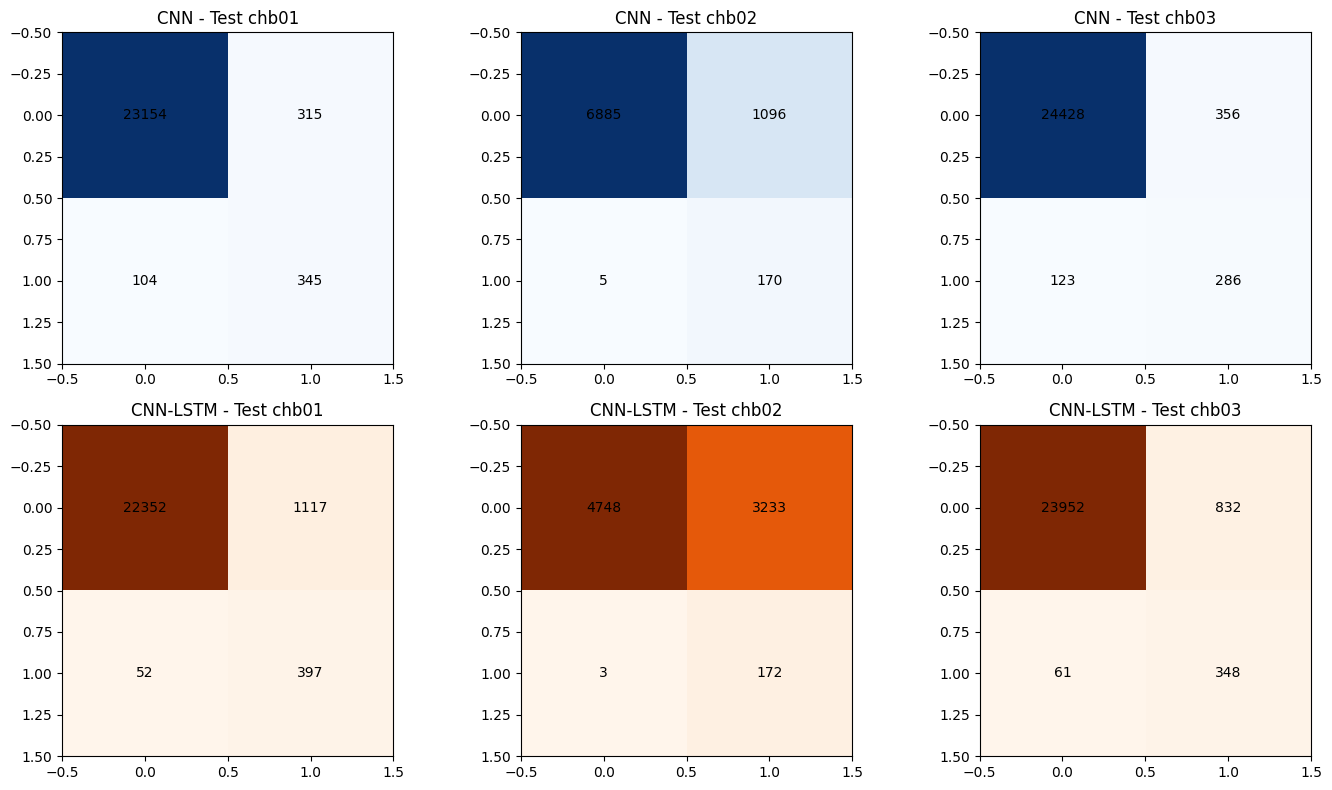

In [ ]:
# Confusion matrices, per fold, for both models
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, r in enumerate(cnn_results):
    cm = np.array(r['confusion_matrix'])
    axes[0, i].imshow(cm, cmap='Blues')
    axes[0, i].set_title(f"CNN - Test {r['test_patient']}")
    for (j, k), val in np.ndenumerate(cm):
        axes[0, i].text(k, j, val, ha='center', va='center')
for i, r in enumerate(cnn_lstm_results):
    cm = np.array(r['confusion_matrix'])
    axes[1, i].imshow(cm, cmap='Oranges')
    axes[1, i].set_title(f"CNN-LSTM - Test {r['test_patient']}")
    for (j, k), val in np.ndenumerate(cm):
        axes[1, i].text(k, j, val, ha='center', va='center')
plt.tight_layout()
plt.show()


### Add-on: Extended Metrics (Specificity, MCC, Mean ± Std) — for the Paper

Specificity (true-negative rate) and Matthews Correlation Coefficient are reported in
addition to the core five metrics, since MCC in particular is considered a more reliable
single-number summary than accuracy or F1 under class imbalance (common in seizure vs.
non-seizure data). Mean ± standard deviation across the 3 LOPO folds is also reported to
show consistency across patients, not just the average.


In [ ]:
def extended_results_df(results, name):
    rows = [{
        'Test Patient': r['test_patient'],
        'Accuracy': round(r['accuracy'], 3),
        'Precision': round(r['precision'], 3),
        'Recall (Sensitivity)': round(r['recall'], 3),
        'Specificity': round(r['specificity'], 3) if not np.isnan(r['specificity']) else 'N/A',
        'F1-score': round(r['f1'], 3),
        'MCC': round(r['mcc'], 3) if not np.isnan(r['mcc']) else 'N/A',
        'AUC': round(r['auc'], 3) if not np.isnan(r['auc']) else 'N/A',
    } for r in results]
    df = pd.DataFrame(rows)
    print(f"=== {name} — Extended Per-Fold Metrics ===")
    display(df)
    return df

cnn_ext_df = extended_results_df(cnn_results, 'CNN')
cnn_lstm_ext_df = extended_results_df(cnn_lstm_results, 'CNN-LSTM')

def mean_std_row(results, name):
    def ms(key):
        vals = [r[key] for r in results if not (isinstance(r[key], float) and np.isnan(r[key]))]
        return f"{np.mean(vals):.3f} ± {np.std(vals):.3f}" if vals else 'N/A'
    return {
        'Model': name,
        'Accuracy': ms('accuracy'),
        'Precision': ms('precision'),
        'Recall': ms('recall'),
        'Specificity': ms('specificity'),
        'F1-score': ms('f1'),
        'MCC': ms('mcc'),
        'AUC': ms('auc'),
    }

meanstd_df = pd.DataFrame([
    mean_std_row(cnn_results, 'CNN'),
    mean_std_row(cnn_lstm_results, 'CNN-LSTM'),
])
print("\n=== Mean ± Std Across LOPO Folds (paper-ready summary row) ===")
display(meanstd_df)


=== CNN — Extended Per-Fold Metrics ===


,Test Patient,Accuracy,Precision,Recall (Sensitivity),Specificity,F1-score,MCC,AUC
0,chb01,0.982,0.523,0.768,0.987,0.622,0.626,0.981
1,chb02,0.865,0.134,0.971,0.863,0.236,0.334,0.981
2,chb03,0.981,0.445,0.699,0.986,0.544,0.549,0.953


=== CNN-LSTM — Extended Per-Fold Metrics ===


,Test Patient,Accuracy,Precision,Recall (Sensitivity),Specificity,F1-score,MCC,AUC
0,chb01,0.951,0.262,0.884,0.952,0.404,0.466,0.980
1,chb02,0.603,0.051,0.983,0.595,0.096,0.170,0.966
2,chb03,0.965,0.295,0.851,0.966,0.438,0.489,0.965



=== Mean ± Std Across LOPO Folds (paper-ready summary row) ===


,Model,Accuracy,Precision,Recall,Specificity,F1-score,MCC,AUC
0,CNN,0.943 ± 0.055,0.367 ± 0.168,0.813 ± 0.116,0.945 ± 0.058,0.467 ± 0.167,0.503 ± 0.124,0.972 ± 0.013
1,CNN-LSTM,0.840 ± 0.167,0.203 ± 0.108,0.906 ± 0.056,0.838 ± 0.172,0.313 ± 0.154,0.375 ± 0.145,0.970 ± 0.007


### Add-on: ROC and Precision-Recall Curves

ROC curves are the conventional choice, but Precision-Recall curves are generally more
informative for imbalanced problems like seizure detection (where non-seizure segments
vastly outnumber seizure segments) — both are included.


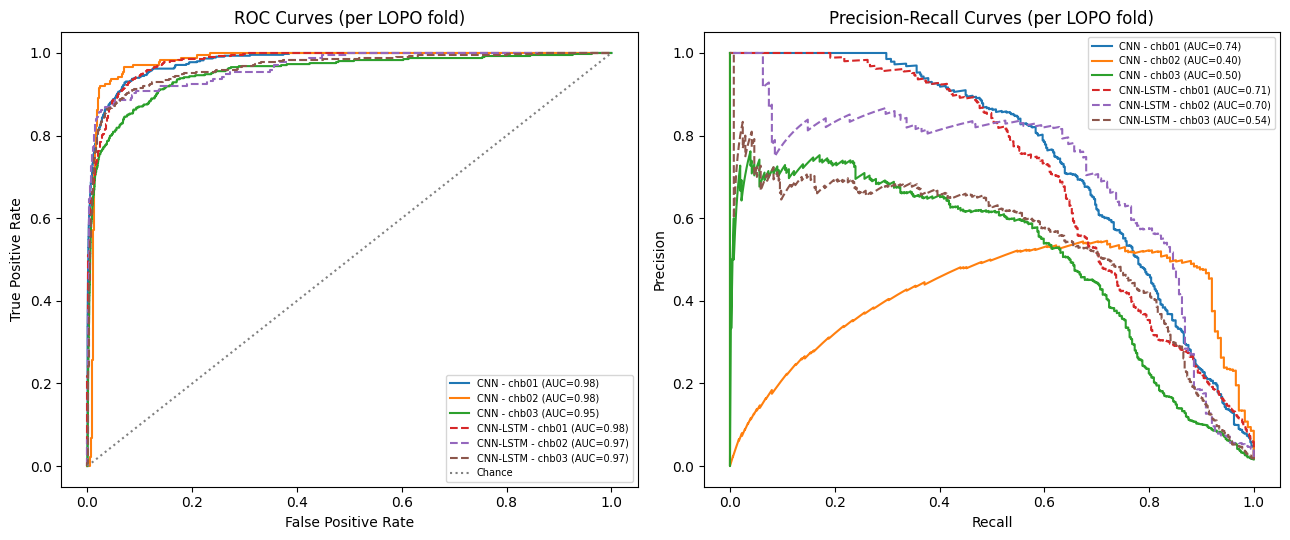

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for r in cnn_results:
    fpr, tpr, _ = roc_curve(r['y_test'], r['y_prob'])
    axes[0].plot(fpr, tpr, label=f"CNN - {r['test_patient']} (AUC={r['auc']:.2f})", linestyle='-')
for r in cnn_lstm_results:
    fpr, tpr, _ = roc_curve(r['y_test'], r['y_prob'])
    axes[0].plot(fpr, tpr, label=f"CNN-LSTM - {r['test_patient']} (AUC={r['auc']:.2f})", linestyle='--')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle=':', label='Chance')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves (per LOPO fold)')
axes[0].legend(fontsize=7)

for r in cnn_results:
    prec, rec, _ = precision_recall_curve(r['y_test'], r['y_prob'])
    pr_auc = auc(rec, prec)
    axes[1].plot(rec, prec, label=f"CNN - {r['test_patient']} (AUC={pr_auc:.2f})", linestyle='-')
for r in cnn_lstm_results:
    prec, rec, _ = precision_recall_curve(r['y_test'], r['y_prob'])
    pr_auc = auc(rec, prec)
    axes[1].plot(rec, prec, label=f"CNN-LSTM - {r['test_patient']} (AUC={pr_auc:.2f})", linestyle='--')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves (per LOPO fold)')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()


## Step 6: Comparison Across Different Numbers of Features

Re-run LOPO validation for both models using the top-K most important features
(from the Random Forest ranking in Step 3), for several values of K.


In [24]:
FEATURE_COUNTS = [10, 20, 30, len(feature_names)]   # last entry = full feature set
feature_count_results = []

for k in FEATURE_COUNTS:
    top_k_features = TOP_FEATURE_ORDER[:k]
    print(f"\n--- Evaluating with top {k} features ---")

    cnn_k = run_lopo(model_type='cnn', feature_names_subset=top_k_features, epochs=20, store_model=False)
    cnn_lstm_k = run_lopo(model_type='cnn_lstm', feature_names_subset=top_k_features, epochs=20, store_model=False)

    feature_count_results.append({
        'n_features': k,
        'CNN_Accuracy': np.mean([r['accuracy'] for r in cnn_k]),
        'CNN_F1': np.mean([r['f1'] for r in cnn_k]),
        'CNN_AUC': np.nanmean([r['auc'] for r in cnn_k]),
        'CNN_LSTM_Accuracy': np.mean([r['accuracy'] for r in cnn_lstm_k]),
        'CNN_LSTM_F1': np.mean([r['f1'] for r in cnn_lstm_k]),
        'CNN_LSTM_AUC': np.nanmean([r['auc'] for r in cnn_lstm_k]),
    })

feature_count_df = pd.DataFrame(feature_count_results).round(3)
print("\n=== Performance vs Number of Features (Averaged over LOPO folds) ===")
display(feature_count_df)



--- Evaluating with top 10 features ---
[CNN] Test=chb01 | Acc=0.980 F1=0.620 AUC=0.990 TrainTime=19.1s InferTime/seg=0.071ms
[CNN] Test=chb02 | Acc=0.702 F1=0.123 AUC=0.970 TrainTime=39.1s InferTime/seg=0.162ms
[CNN] Test=chb03 | Acc=0.972 F1=0.490 AUC=0.977 TrainTime=24.8s InferTime/seg=0.069ms
[CNN_LSTM] Test=chb01 | Acc=0.942 F1=0.384 AUC=0.990 TrainTime=33.8s InferTime/seg=0.137ms
[CNN_LSTM] Test=chb02 | Acc=0.770 F1=0.153 AUC=0.984 TrainTime=145.8s InferTime/seg=0.205ms
[CNN_LSTM] Test=chb03 | Acc=0.970 F1=0.425 AUC=0.966 TrainTime=87.4s InferTime/seg=0.116ms

--- Evaluating with top 20 features ---
[CNN] Test=chb01 | Acc=0.990 F1=0.698 AUC=0.988 TrainTime=24.2s InferTime/seg=0.073ms
[CNN] Test=chb02 | Acc=0.806 F1=0.176 AUC=0.977 TrainTime=36.1s InferTime/seg=0.146ms
[CNN] Test=chb03 | Acc=0.981 F1=0.585 AUC=0.974 TrainTime=26.4s InferTime/seg=0.104ms
[CNN_LSTM] Test=chb01 | Acc=0.947 F1=0.399 AUC=0.991 TrainTime=37.6s InferTime/seg=0.117ms
[CNN_LSTM] Test=chb02 | Acc=0.694 F1=

,n_features,CNN_Accuracy,CNN_F1,CNN_AUC,CNN_LSTM_Accuracy,CNN_LSTM_F1,CNN_LSTM_AUC
0,10,0.885,0.411,0.979,0.894,0.321,0.980
1,20,0.926,0.486,0.980,0.866,0.299,0.971
2,30,0.964,0.548,0.975,0.917,0.407,0.984
3,48,0.947,0.468,0.972,0.895,0.338,0.977


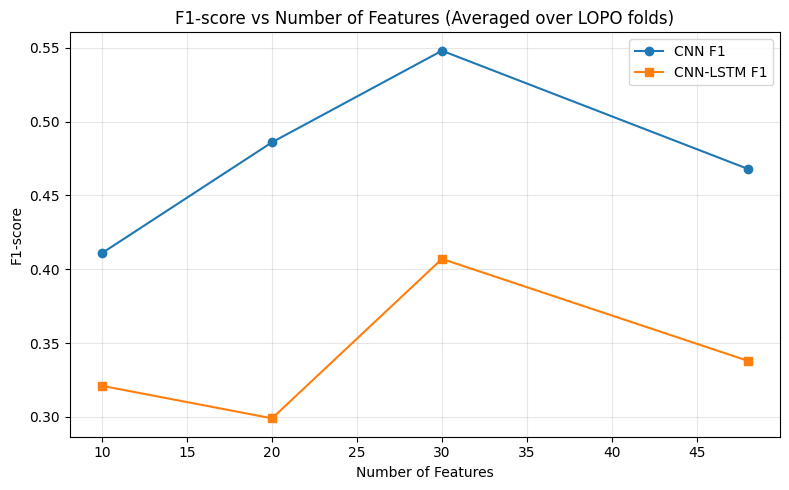

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(feature_count_df['n_features'], feature_count_df['CNN_F1'], marker='o', label='CNN F1')
plt.plot(feature_count_df['n_features'], feature_count_df['CNN_LSTM_F1'], marker='s', label='CNN-LSTM F1')
plt.xlabel('Number of Features')
plt.ylabel('F1-score')
plt.title('F1-score vs Number of Features (Averaged over LOPO folds)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Step 7: Prediction Time

Training time and per-segment inference time were captured for every LOPO fold in
Step 4 (`train_time_sec`, `infer_time_per_sample_sec`). Summarize and compare here.


In [26]:
timing_rows = []
for r in cnn_results:
    timing_rows.append({'Model': 'CNN', 'Test Patient': r['test_patient'],
                         'Train Time (s)': round(r['train_time_sec'], 2),
                         'Inference Time/Segment (ms)': round(r['infer_time_per_sample_sec'] * 1000, 4)})
for r in cnn_lstm_results:
    timing_rows.append({'Model': 'CNN-LSTM', 'Test Patient': r['test_patient'],
                         'Train Time (s)': round(r['train_time_sec'], 2),
                         'Inference Time/Segment (ms)': round(r['infer_time_per_sample_sec'] * 1000, 4)})

timing_df = pd.DataFrame(timing_rows)
print("=== Training & Inference Timing per Fold ===")
display(timing_df)

timing_summary = timing_df.groupby('Model').agg(
    Avg_Train_Time_s=('Train Time (s)', 'mean'),
    Avg_Inference_Time_per_Segment_ms=('Inference Time/Segment (ms)', 'mean')
).round(4).reset_index()

print("\n=== Timing Summary: CNN vs CNN-LSTM ===")
display(timing_summary)


=== Training & Inference Timing per Fold ===


,Model,Test Patient,Train Time (s),Inference Time/Segment (ms)
0,CNN,chb01,37.80,0.1316
1,CNN,chb02,142.26,0.1076
2,CNN,chb03,36.42,0.0849
3,CNN-LSTM,chb01,108.05,0.2175
4,CNN-LSTM,chb02,163.11,0.2101
5,CNN-LSTM,chb03,106.13,0.2061



=== Timing Summary: CNN vs CNN-LSTM ===


,Model,Avg_Train_Time_s,Avg_Inference_Time_per_Segment_ms
0,CNN,72.1600,0.1080
1,CNN-LSTM,125.7633,0.2112


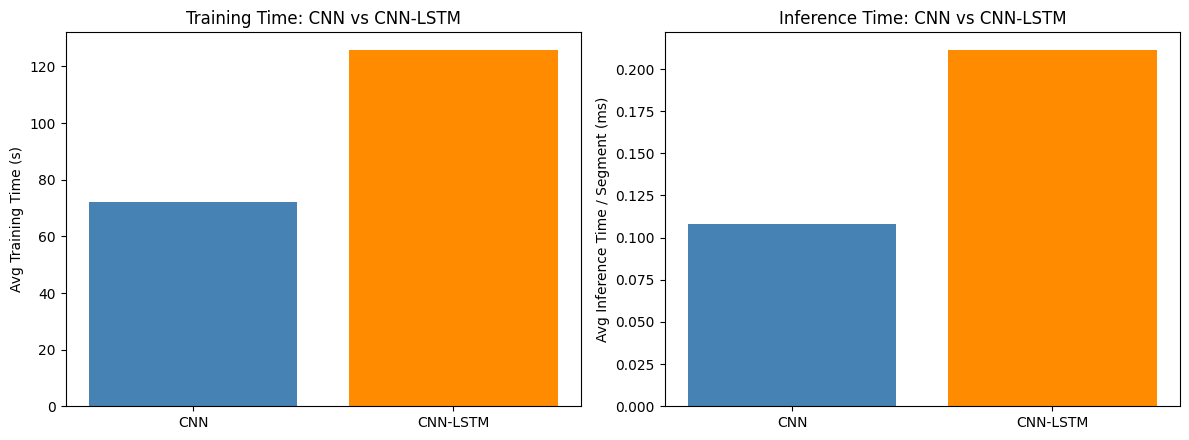

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(timing_summary['Model'], timing_summary['Avg_Train_Time_s'], color=['steelblue', 'darkorange'])
axes[0].set_ylabel('Avg Training Time (s)')
axes[0].set_title('Training Time: CNN vs CNN-LSTM')

axes[1].bar(timing_summary['Model'], timing_summary['Avg_Inference_Time_per_Segment_ms'],
            color=['steelblue', 'darkorange'])
axes[1].set_ylabel('Avg Inference Time / Segment (ms)')
axes[1].set_title('Inference Time: CNN vs CNN-LSTM')

plt.tight_layout()
plt.show()


## Step 8 (Add-on): External Validation on a Genuinely Unseen 4th Patient

Everything above (Steps 1-7) uses Leave-One-Patient-Out across **chb01/chb02/chb03**,
which is a fair test but still draws all 3 patients from the same pool used at some
point in training. This step adds a stricter, independent check: both models are
**retrained from scratch on all of chb01+chb02+chb03 combined**, then evaluated on
**chb04 — a patient never used anywhere in training or hyperparameter selection.**
This mirrors what a professor / reviewer typically means by "test on unseen data" and
reuses the exact same preprocessing, segmentation, and feature-extraction functions
already defined above (Steps 1-3), so results are directly comparable.


In [28]:
EXTERNAL_PATIENT = 'chb04'
ext_patient_dir = os.path.join(DATASET_PATH, EXTERNAL_PATIENT)
os.makedirs(ext_patient_dir, exist_ok=True)

# 1) Ensure the patient's summary file is present (download if missing)
ext_summary_path = os.path.join(ext_patient_dir, f"{EXTERNAL_PATIENT}-summary.txt")
if not os.path.isfile(ext_summary_path):
    print(f"Downloading {EXTERNAL_PATIENT}-summary.txt ...")
    url = f"{PHYSIONET_BASE_URL}/{EXTERNAL_PATIENT}/{EXTERNAL_PATIENT}-summary.txt"
    os.system(f'wget -q -O "{ext_summary_path}" "{url}"')
assert os.path.isfile(ext_summary_path), "Could not obtain chb04 summary file — check internet access."
print("Summary file OK:", ext_summary_path)

# 2) Find which seizure EDF files chb04 needs, and download only those
ext_seizures_by_file = parse_summary_file(ext_summary_path)
ext_needed_files = sorted(ext_seizures_by_file.keys())
print(f"{EXTERNAL_PATIENT}: {len(ext_needed_files)} seizure file(s) needed -> {ext_needed_files}")

for fname in ext_needed_files:
    dest = os.path.join(ext_patient_dir, fname)
    if os.path.isfile(dest) and os.path.getsize(dest) > 1_000_000:
        print(f"  [SKIP] already present: {fname} ({os.path.getsize(dest)/1e6:.1f} MB)")
        continue
    url = f"{PHYSIONET_BASE_URL}/{EXTERNAL_PATIENT}/{fname}"
    print(f"  Downloading {fname} ...")
    exit_code = os.system(f'wget -q -O "{dest}" "{url}"')
    if exit_code != 0 or not os.path.isfile(dest) or os.path.getsize(dest) < 1_000_000:
        print(f"    [WARN] Download failed or file too small for {fname} (url: {url})")
    else:
        print(f"    -> {os.path.getsize(dest)/1e6:.1f} MB")


Summary file OK: /content/drive/MyDrive/EEG_Dataset/CHB Dataset/CHB Dataset/chb04/chb04-summary.txt
chb04: 3 seizure file(s) needed -> ['chb04_05.edf', 'chb04_08.edf', 'chb04_28.edf']
  [SKIP] already present: chb04_05.edf (112.3 MB)
  [SKIP] already present: chb04_08.edf (177.0 MB)
  [SKIP] already present: chb04_28.edf (177.2 MB)


In [29]:
# 3) Build the seizure-info dataframe, preprocess, segment, and extract features —
#    reusing the exact same functions from Steps 1-3, unchanged.
ext_seizure_df = get_patient_seizure_info(EXTERNAL_PATIENT, DATASET_PATH)
print(f"{EXTERNAL_PATIENT}: {len(ext_seizure_df)} seizure annotation records loaded")
display(ext_seizure_df[['patient', 'file', 'seizure_idx', 'start_sec', 'end_sec', 'duration_sec']])

ext_segs, ext_labs, ext_chans = load_and_segment_patient(EXTERNAL_PATIENT, DATASET_PATH, ext_seizure_df)
print(f"\n{EXTERNAL_PATIENT}: {len(ext_labs)} total segments "
      f"({int(ext_labs.sum())} seizure, {int(len(ext_labs) - ext_labs.sum())} non-seizure)")

ext_seq_X, ext_flat_X, ext_feat_names = build_feature_dataset(ext_segs)
assert ext_feat_names == feature_names, "Feature ordering mismatch between chb04 and training patients!"
print(f"External test set ready: seq_X {ext_seq_X.shape}, flat_X {ext_flat_X.shape}")


chb04: 4 seizure annotation records loaded


,patient,file,seizure_idx,start_sec,end_sec,duration_sec
0,chb04,chb04_05.edf,1,7804,7853,49
1,chb04,chb04_08.edf,1,6446,6557,111
2,chb04,chb04_28.edf,1,1679,1781,102
3,chb04,chb04_28.edf,2,3782,3898,116


  chb04/chb04_05.edf: 9535 segments (50 seizure, 9485 non-seizure)
  chb04/chb04_08.edf: 14399 segments (112 seizure, 14287 non-seizure)
  chb04/chb04_28.edf: 14422 segments (220 seizure, 14202 non-seizure)

chb04: 38356 total segments (382 seizure, 37974 non-seizure)
External test set ready: seq_X (38356, 4, 12), flat_X (38356, 48)


In [30]:
def run_external_validation(model_type='cnn', epochs=30, batch_size=64, verbose=0):
    """
    Trains on ALL of chb01+chb02+chb03 (full pooled training set, no held-out fold),
    then evaluates once on the fully external chb04 patient.
    """
    col_idx = list(range(len(feature_names)))
    col_idx_seq = list(range(len(BASE_FEATURE_NAMES)))

    if model_type == 'cnn':
        X_train = np.concatenate([patient_data[p]['flat_X'][:, col_idx] for p in PATIENTS], axis=0)
        X_test = ext_flat_X[:, col_idx]
    else:
        X_train = np.concatenate([patient_data[p]['seq_X'][:, :, col_idx_seq] for p in PATIENTS], axis=0)
        X_test = ext_seq_X[:, :, col_idx_seq]

    y_train = np.concatenate([patient_data[p]['labels'] for p in PATIENTS], axis=0)
    y_test = ext_labs

    if model_type == 'cnn':
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        X_train = X_train[..., np.newaxis]
        X_test = X_test[..., np.newaxis]
        model = build_cnn(X_train.shape[1])
    else:
        n_t, n_f = X_train.shape[1], X_train.shape[2]
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train.reshape(-1, n_f)).reshape(-1, n_t, n_f)
        X_test = scaler.transform(X_test.reshape(-1, n_f)).reshape(-1, n_t, n_f)
        X_train = X_train[..., np.newaxis]
        X_test = X_test[..., np.newaxis]
        model = build_cnn_lstm(n_t, n_f)

    es = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    pos = max(1, int(y_train.sum()))
    neg = max(1, len(y_train) - pos)
    class_weight = {0: 1.0, 1: neg / pos}

    t0 = time.time()
    model.fit(X_train, y_train, validation_split=0.15, epochs=epochs, batch_size=batch_size,
              callbacks=[es], verbose=verbose, class_weight=class_weight)
    train_time = time.time() - t0

    TRAINED_MODELS_EXTERNAL[model_type] = model

    t1 = time.time()
    y_prob = model.predict(X_test, verbose=0).ravel()
    infer_time_per_sample = (time.time() - t1) / max(1, len(X_test))
    y_pred = (y_prob >= 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    mcc = matthews_corrcoef(y_test, y_pred) if len(np.unique(y_test)) > 1 else np.nan

    result = {
        'model': model_type,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'specificity': specificity,
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'mcc': mcc,
        'auc': roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else np.nan,
        'confusion_matrix': cm.tolist(),
        'train_time_sec': train_time,
        'infer_time_per_sample_sec': infer_time_per_sample,
        'n_train': len(y_train),
        'n_test': len(y_test),
        'y_test': y_test.tolist(),
        'y_prob': y_prob.tolist(),
    }
    auc_str = f"{result['auc']:.3f}" if not np.isnan(result['auc']) else "N/A"
    print(f"[{model_type.upper()}] External test ({EXTERNAL_PATIENT}) | "
          f"Acc={result['accuracy']:.3f} F1={result['f1']:.3f} AUC={auc_str} "
          f"TrainTime={train_time:.1f}s InferTime/seg={infer_time_per_sample*1000:.3f}ms")
    return result

print("=== External Validation: CNN (train on chb01+02+03, test on chb04) ===")
cnn_external = run_external_validation(model_type='cnn', epochs=30)

print("\n=== External Validation: CNN-LSTM (train on chb01+02+03, test on chb04) ===")
cnn_lstm_external = run_external_validation(model_type='cnn_lstm', epochs=30)


=== External Validation: CNN (train on chb01+02+03, test on chb04) ===
[CNN] External test (chb04) | Acc=0.985 F1=0.386 AUC=0.878 TrainTime=71.1s InferTime/seg=0.112ms

=== External Validation: CNN-LSTM (train on chb01+02+03, test on chb04) ===
[CNN_LSTM] External test (chb04) | Acc=0.910 F1=0.123 AUC=0.878 TrainTime=128.6s InferTime/seg=0.108ms


=== External Validation Results (unseen patient: chb04) ===


,Model,accuracy,precision,recall,specificity,f1,mcc,auc
0,CNN,0.985,0.324,0.479,0.990,0.386,0.387,0.878
1,CNN-LSTM,0.910,0.068,0.631,0.913,0.123,0.187,0.878


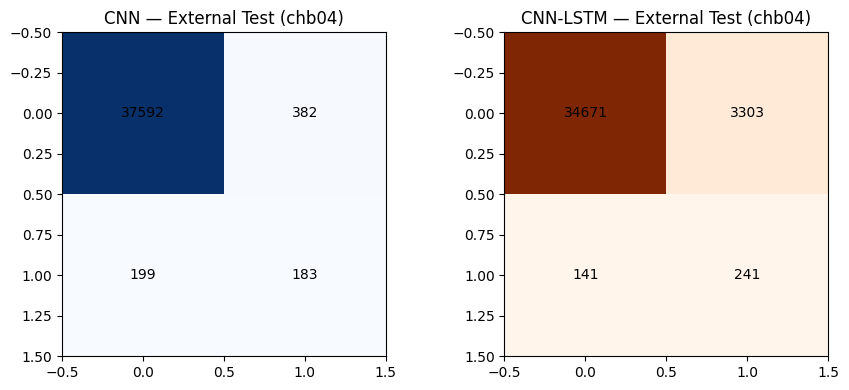

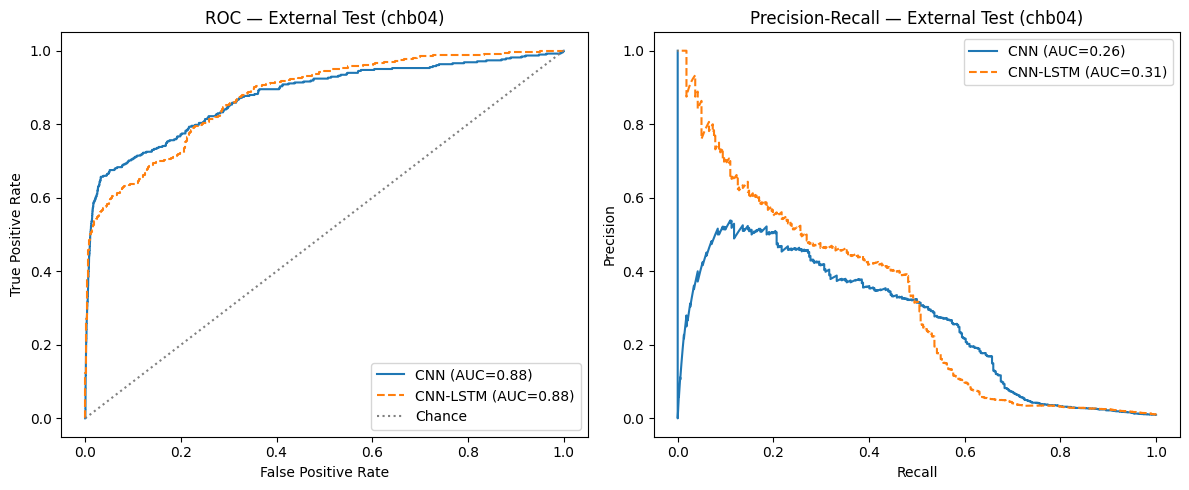

In [31]:
# Results table for the external (chb04) holdout
external_df = pd.DataFrame([
    {'Model': 'CNN', **{k: round(v, 3) if isinstance(v, float) and not np.isnan(v) else v
                         for k, v in cnn_external.items() if k in
                         ['accuracy', 'precision', 'recall', 'specificity', 'f1', 'mcc', 'auc']}},
    {'Model': 'CNN-LSTM', **{k: round(v, 3) if isinstance(v, float) and not np.isnan(v) else v
                              for k, v in cnn_lstm_external.items() if k in
                              ['accuracy', 'precision', 'recall', 'specificity', 'f1', 'mcc', 'auc']}},
])
print(f"=== External Validation Results (unseen patient: {EXTERNAL_PATIENT}) ===")
display(external_df)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for i, (r, name, cmap) in enumerate([(cnn_external, 'CNN', 'Blues'), (cnn_lstm_external, 'CNN-LSTM', 'Oranges')]):
    cm = np.array(r['confusion_matrix'])
    axes[i].imshow(cm, cmap=cmap)
    axes[i].set_title(f"{name} — External Test ({EXTERNAL_PATIENT})")
    for (j, k), val in np.ndenumerate(cm):
        axes[i].text(k, j, val, ha='center', va='center')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for r, name, style in [(cnn_external, 'CNN', '-'), (cnn_lstm_external, 'CNN-LSTM', '--')]:
    fpr, tpr, _ = roc_curve(r['y_test'], r['y_prob'])
    axes[0].plot(fpr, tpr, style, label=f"{name} (AUC={r['auc']:.2f})")
    prec, rec, _ = precision_recall_curve(r['y_test'], r['y_prob'])
    pr_auc = auc(rec, prec)
    axes[1].plot(rec, prec, style, label=f"{name} (AUC={pr_auc:.2f})")

axes[0].plot([0, 1], [0, 1], color='gray', linestyle=':', label='Chance')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'ROC — External Test ({EXTERNAL_PATIENT})'); axes[0].legend()
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title(f'Precision-Recall — External Test ({EXTERNAL_PATIENT})'); axes[1].legend()
plt.tight_layout()
plt.show()


## Step 9: Preictal Feature Analysis

Steps 1-8 treat each 2s window independently and label it by overlap with the seizure
interval itself — that is **seizure detection**. This step instead asks the genuinely
different, prediction-oriented question: **how long before a seizure starts do EEG
features begin to deviate from the patient's own interictal baseline, and which
features move first / fastest / longest?**

For every seizure event (chb01-chb03, plus chb04 from Step 8 — more events gives more
robust statistics), a continuous timeline is built covering an interictal **baseline**
period followed immediately by a **preictal** period leading up to seizure **onset**
(ictal). The same 2s/50%-overlap windowing and the same 12 base features from Step 3
are computed continuously across this timeline (this time per-window, not per
sub-window, since we need one feature value per timestamp).


In [32]:
def extract_continuous_timeline_features(edf_path, seizure_start_sec,
                                          max_preictal_min=MAX_PREICTAL_MINUTES,
                                          baseline_min=BASELINE_MINUTES,
                                          window_sec=WINDOW_SEC, overlap=OVERLAP):
    """
    Reads only the [baseline][preictal] segment of one EDF file leading up to a single
    seizure's onset (never touching the ictal period itself), band-pass filters it, and
    computes a per-2s-window (50% overlap) feature timeline.

    Returns a DataFrame with columns: 'time_to_onset_sec' (negative -> before onset),
    'phase' ('baseline' or 'preictal'), and one column per entry in BASE_FEATURE_NAMES.
    Returns None if not enough recording exists before the seizure to build both phases.
    """
    total_before_sec = (max_preictal_min + baseline_min) * 60
    tmin = max(0.0, seizure_start_sec - total_before_sec)
    tmax = seizure_start_sec
    if tmax <= tmin:
        return None

    try:
        raw = mne.io.read_raw_edf(edf_path, preload=False, verbose='ERROR')
        rec_dur = raw.times[-1]
        tmax = min(tmax, rec_dur)
        if tmax <= tmin:
            return None
        raw.crop(tmin=tmin, tmax=tmax)
        raw.load_data()
    except Exception as e:
        print(f"  [WARN] Could not read/crop {edf_path}: {e}")
        return None

    fs = int(round(raw.info['sfreq']))
    data = bandpass_filter(raw.get_data(), fs=fs)

    win = int(window_sec * fs)
    step = int(win * (1 - overlap))
    n_samples = data.shape[1]
    preictal_boundary_sec = seizure_start_sec - max_preictal_min * 60

    rows = []
    start = 0
    while start + win <= n_samples:
        seg = data[:, start:start + win]
        avg_signal = seg.mean(axis=0)
        feats = extract_subwindow_features(avg_signal, fs)
        window_center_abs_sec = tmin + (start + win / 2) / fs
        time_to_onset = window_center_abs_sec - seizure_start_sec
        phase = 'preictal' if window_center_abs_sec >= preictal_boundary_sec else 'baseline'
        row = {'time_to_onset_sec': time_to_onset, 'phase': phase}
        row.update(feats)
        rows.append(row)
        start += step

    return pd.DataFrame(rows)


In [33]:
# Build a timeline for every seizure event across chb01-chb03 (+ chb04 from Step 8, if available)
_event_cols = ['patient', 'file', 'edf_path', 'seizure_idx', 'start_sec', 'end_sec']
if 'ext_seizure_df' in globals():
    all_seizure_events = pd.concat([seizure_df[_event_cols], ext_seizure_df[_event_cols]], ignore_index=True)
else:
    all_seizure_events = seizure_df[_event_cols].copy()

preictal_timelines = {}
print(f"Extracting preictal timelines for {len(all_seizure_events)} seizure event(s)...")
for _, row in all_seizure_events.iterrows():
    key = (row['patient'], row['file'], int(row['seizure_idx']))
    df_tl = extract_continuous_timeline_features(row['edf_path'], row['start_sec'])
    if df_tl is None:
        print(f"  [SKIP] {key}: could not build timeline (not enough recording before onset)")
        continue
    n_baseline = (df_tl['phase'] == 'baseline').sum()
    n_preictal = (df_tl['phase'] == 'preictal').sum()
    if n_baseline < 3 or n_preictal < 3:
        print(f"  [SKIP] {key}: insufficient baseline ({n_baseline}) or preictal ({n_preictal}) windows")
        continue
    preictal_timelines[key] = df_tl
    print(f"  {key}: {n_baseline} baseline + {n_preictal} preictal windows")

print(f"\nUsable seizure timelines: {len(preictal_timelines)} / {len(all_seizure_events)}")


Extracting preictal timelines for 21 seizure event(s)...
  ('chb01', 'chb01_03.edf', 1): 599 baseline + 1800 preictal windows
  [SKIP] ('chb01', 'chb01_04.edf', 1): insufficient baseline (0) or preictal (1466) windows
  [SKIP] ('chb01', 'chb01_15.edf', 1): insufficient baseline (0) or preictal (1731) windows
  [SKIP] ('chb01', 'chb01_16.edf', 1): insufficient baseline (0) or preictal (1014) windows
  [SKIP] ('chb01', 'chb01_18.edf', 1): insufficient baseline (0) or preictal (1719) windows
  [SKIP] ('chb01', 'chb01_21.edf', 1): insufficient baseline (0) or preictal (326) windows
  ('chb01', 'chb01_26.edf', 1): 61 baseline + 1800 preictal windows
  [SKIP] ('chb02', 'chb02_16.edf', 1): insufficient baseline (0) or preictal (129) windows
  ('chb02', 'chb02_16+.edf', 1): 599 baseline + 1800 preictal windows
  ('chb02', 'chb02_19.edf', 1): 599 baseline + 1800 preictal windows
  [SKIP] ('chb03', 'chb03_01.edf', 1): insufficient baseline (0) or preictal (361) windows
  [SKIP] ('chb03', 'chb03_

### Feature Deviation Onset Detection

For each seizure's timeline, every feature is z-scored against its own **baseline
period** (so each seizure event supplies its own interictal reference — the correct
way to control for inter-patient and inter-session baseline differences). The earliest
point at which a feature's `|z-score|` exceeds a threshold **and stays above it for
several consecutive windows** (to reject single-window noise) marks that feature's
deviation onset for that seizure.


In [34]:
def add_zscores(df_tl, features=BASE_FEATURE_NAMES):
    baseline = df_tl[df_tl['phase'] == 'baseline']
    for feat in features:
        mu = baseline[feat].mean()
        sigma = baseline[feat].std()
        sigma = sigma if sigma > 1e-9 else 1e-9
        df_tl[f'{feat}_z'] = (df_tl[feat] - mu) / sigma
    return df_tl


def find_deviation_onset(df_tl, feature, z_thresh=DEVIATION_Z_THRESH, sustain=SUSTAIN_WINDOWS):
    """Earliest time_to_onset_sec (most negative) at which |z| stays >= z_thresh for
    `sustain` consecutive windows. Returns np.nan if no such sustained deviation occurs."""
    df_sorted = df_tl.sort_values('time_to_onset_sec').reset_index(drop=True)
    z = df_sorted[f'{feature}_z'].abs().values
    t = df_sorted['time_to_onset_sec'].values
    for i in range(len(z) - sustain + 1):
        if np.all(z[i:i + sustain] >= z_thresh):
            return t[i]
    return np.nan


def max_rate_of_change(df_tl, feature):
    """Max |slope| of the z-scored feature during the preictal phase (per second)."""
    pre = df_tl[df_tl['phase'] == 'preictal'].sort_values('time_to_onset_sec')
    if len(pre) < 2:
        return np.nan
    z = pre[f'{feature}_z'].values
    t = pre['time_to_onset_sec'].values
    grad = np.gradient(z, t)
    return float(np.max(np.abs(grad)))


per_seizure_onset_records = []
for key, df_tl in preictal_timelines.items():
    df_tl = add_zscores(df_tl)
    preictal_timelines[key] = df_tl
    patient, fname, seiz_idx = key
    for feat in BASE_FEATURE_NAMES:
        onset_sec = find_deviation_onset(df_tl, feat)
        per_seizure_onset_records.append({
            'patient': patient, 'file': fname, 'seizure_idx': seiz_idx, 'feature': feat,
            'onset_time_min_before_seizure': -onset_sec / 60 if not np.isnan(onset_sec) else np.nan,
            'detected': not np.isnan(onset_sec),
            'max_rate_of_change': max_rate_of_change(df_tl, feat),
        })

onset_records_df = pd.DataFrame(per_seizure_onset_records)
print(f"Computed deviation onsets for {len(BASE_FEATURE_NAMES)} features across "
      f"{len(preictal_timelines)} seizure events ({len(onset_records_df)} feature-event pairs).")


Computed deviation onsets for 12 features across 10 seizure events (120 feature-event pairs).


### Feature Ranking: Earliest Warning, Longest Signal, Fastest Change

Per-seizure onset times are aggregated per feature to answer: which feature gives the
**earliest** warning, which stays **abnormal longest**, and which changes **fastest**
as the seizure approaches.


In [35]:
feature_temporal_rows = []
for feat in BASE_FEATURE_NAMES:
    sub = onset_records_df[onset_records_df['feature'] == feat]
    detected = sub[sub['detected']]
    feature_temporal_rows.append({
        'feature': feat,
        'detection_rate': round(len(detected) / len(sub), 3) if len(sub) else np.nan,
        'mean_earliest_onset_min': round(detected['onset_time_min_before_seizure'].mean(), 2) if len(detected) else np.nan,
        'mean_duration_altered_min': round(detected['onset_time_min_before_seizure'].mean(), 2) if len(detected) else np.nan,
        'mean_max_rate_of_change': round(sub['max_rate_of_change'].mean(), 4),
    })

feature_temporal_summary = pd.DataFrame(feature_temporal_rows)

print("=== Feature Temporal Summary (all features) ===")
display(feature_temporal_summary.sort_values('mean_earliest_onset_min'))

RELIABLE_MIN_DETECTION_RATE = 0.5
reliable = feature_temporal_summary[feature_temporal_summary['detection_rate'] >= RELIABLE_MIN_DETECTION_RATE].copy()

earliest_warning_feature = (reliable.sort_values('mean_earliest_onset_min').iloc[0]
                             if len(reliable) else None)
longest_duration_feature = (reliable.sort_values('mean_duration_altered_min', ascending=False).iloc[0]
                             if len(reliable) else None)
fastest_changing_feature = (feature_temporal_summary.sort_values('mean_max_rate_of_change', ascending=False).iloc[0]
                             if len(feature_temporal_summary) else None)

print(f"\n(Features with detection rate >= {RELIABLE_MIN_DETECTION_RATE:.0%} considered 'reliable' for ranking)")
print("\n=== Feature Response Speed Comparison ===")
speed_rows = []
if earliest_warning_feature is not None:
    speed_rows.append({'Question': 'Earliest warning', 'Feature': earliest_warning_feature['feature'],
                        'Value': f"{earliest_warning_feature['mean_earliest_onset_min']:.2f} min before onset"})
if longest_duration_feature is not None:
    speed_rows.append({'Question': 'Longest duration altered', 'Feature': longest_duration_feature['feature'],
                        'Value': f"{longest_duration_feature['mean_duration_altered_min']:.2f} min"})
if fastest_changing_feature is not None:
    speed_rows.append({'Question': 'Fastest changing (max |slope|)', 'Feature': fastest_changing_feature['feature'],
                        'Value': f"{fastest_changing_feature['mean_max_rate_of_change']:.4f} z/sec"})
display(pd.DataFrame(speed_rows))


=== Feature Temporal Summary (all features) ===


,feature,detection_rate,mean_earliest_onset_min,mean_duration_altered_min,mean_max_rate_of_change
8,theta_power,0.1,6.10,6.10,0.3318
0,mean,0.9,27.58,27.58,10.8645
1,std,1.0,29.81,29.81,8.2676
4,line_length,1.0,30.74,30.74,4.3795
5,zero_crossings,1.0,31.37,31.37,3.5017
3,kurtosis,0.8,32.57,32.57,13.1701
6,entropy,0.8,32.98,32.98,4.8375
2,skew,0.9,34.30,34.30,6.8241
7,delta_power,0.0,NaN,NaN,0.5297
9,alpha_power,0.0,NaN,NaN,0.1583



(Features with detection rate >= 50% considered 'reliable' for ranking)

=== Feature Response Speed Comparison ===


,Question,Feature,Value
0,Earliest warning,mean,27.58 min before onset
1,Longest duration altered,skew,34.30 min
2,Fastest changing (max |slope|),kurtosis,13.1701 z/sec


### Estimating the Effective Preictal Prediction Window

The earliest-warning feature's mean deviation time is mapped onto the standard
candidate windows (5 / 10 / 20 / 30 minutes) requested for reporting.


In [36]:
if earliest_warning_feature is not None:
    observed_min = abs(earliest_warning_feature['mean_earliest_onset_min'])
    candidates = np.array(PREICTAL_WINDOW_CANDIDATES_MIN)
    matched_window = int(candidates[candidates >= observed_min].min()) if (candidates >= observed_min).any() else int(candidates.max())
    print(f"Earliest reliable feature-level deviation observed at ~{observed_min:.1f} minutes before onset "
          f"(feature: '{earliest_warning_feature['feature']}').")
    print(f"Effective preictal prediction window (nearest standard candidate >= observed): {matched_window} minutes.")
    print(f"\nCaveat: based on {len(preictal_timelines)} seizure event(s) only — treat as an initial "
          f"estimate, not a definitive clinical prediction horizon.")
else:
    matched_window = None
    print("No feature showed a sufficiently reliable (>=50% of events) deviation to estimate a window.")


Earliest reliable feature-level deviation observed at ~27.6 minutes before onset (feature: 'mean').
Effective preictal prediction window (nearest standard candidate >= observed): 30 minutes.

Caveat: based on 10 seizure event(s) only — treat as an initial estimate, not a definitive clinical prediction horizon.


### Visualizations

1. Per-event time-series of the top features with baseline/preictal/onset markers.
2. A heatmap of feature deviation intensity over time for a representative event.
3. Aggregated feature-importance-vs-time across all seizure events.
4. Feature response-speed comparison bars.


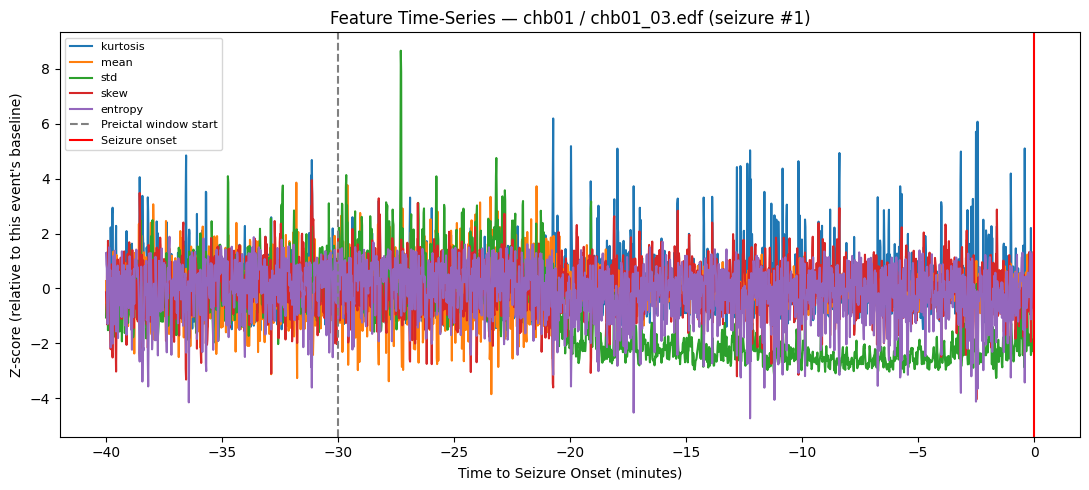

In [37]:
# 1) Time-series of the top-5 earliest/strongest features for one representative seizure event
if preictal_timelines:
    top5_features = feature_temporal_summary.sort_values('mean_max_rate_of_change', ascending=False)['feature'].head(5).tolist()
    example_key = list(preictal_timelines.keys())[0]
    df_ex = preictal_timelines[example_key].sort_values('time_to_onset_sec')
    t_min = df_ex['time_to_onset_sec'] / 60.0
    preictal_boundary_min = -MAX_PREICTAL_MINUTES

    plt.figure(figsize=(11, 5))
    for feat in top5_features:
        plt.plot(t_min, df_ex[f'{feat}_z'], label=feat)
    plt.axvline(preictal_boundary_min, color='gray', linestyle='--', label='Preictal window start')
    plt.axvline(0, color='red', linestyle='-', label='Seizure onset')
    plt.xlabel('Time to Seizure Onset (minutes)')
    plt.ylabel("Z-score (relative to this event's baseline)")
    plt.title(f'Feature Time-Series — {example_key[0]} / {example_key[1]} (seizure #{example_key[2]})')
    plt.legend(fontsize=8, loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("No usable timelines to plot.")


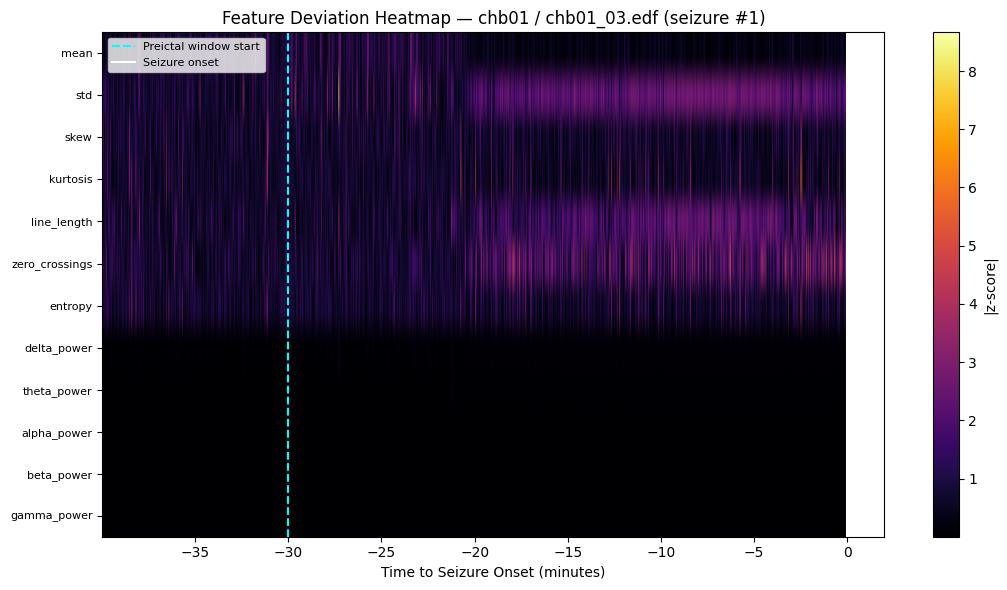

In [38]:
# 2) Heatmap of |z-score| over time for the same representative event, all features
if preictal_timelines:
    z_cols = [f'{f}_z' for f in BASE_FEATURE_NAMES]
    heat_data = df_ex[z_cols].abs().T.values
    plt.figure(figsize=(11, 6))
    im = plt.imshow(heat_data, aspect='auto', cmap='inferno',
                     extent=[t_min.min(), t_min.max(), len(BASE_FEATURE_NAMES), 0])
    plt.colorbar(im, label='|z-score|')
    plt.yticks(np.arange(len(BASE_FEATURE_NAMES)) + 0.5, BASE_FEATURE_NAMES, fontsize=8)
    plt.axvline(preictal_boundary_min, color='cyan', linestyle='--', label='Preictal window start')
    plt.axvline(0, color='white', linestyle='-', label='Seizure onset')
    plt.xlabel('Time to Seizure Onset (minutes)')
    plt.title(f'Feature Deviation Heatmap — {example_key[0]} / {example_key[1]} (seizure #{example_key[2]})')
    plt.legend(fontsize=8, loc='upper left')
    plt.tight_layout()
    plt.show()


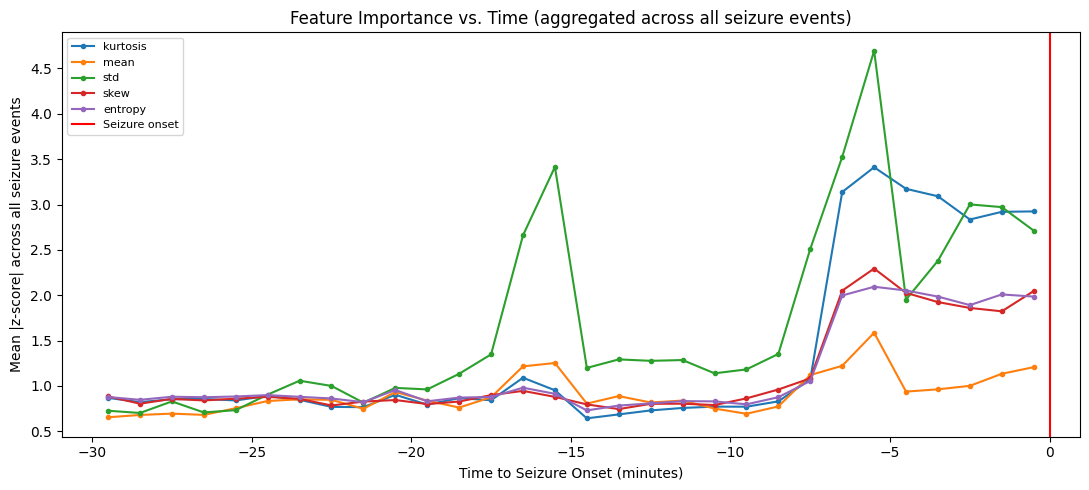

In [39]:
# 3) Feature-importance-vs-time, aggregated across ALL seizure events via 1-minute time bins
if preictal_timelines:
    BIN_WIDTH_MIN = 1.0
    bins_min = np.arange(-MAX_PREICTAL_MINUTES, 0 + BIN_WIDTH_MIN, BIN_WIDTH_MIN)

    agg_rows = []
    for key, df_tl in preictal_timelines.items():
        df_pre = df_tl[df_tl['phase'] == 'preictal'].copy()
        df_pre['t_min'] = df_pre['time_to_onset_sec'] / 60.0
        df_pre['bin'] = pd.cut(df_pre['t_min'], bins=bins_min)
        agg_rows.append(df_pre)
    all_preictal = pd.concat(agg_rows, ignore_index=True) if agg_rows else pd.DataFrame()

    if len(all_preictal):
        top5_agg = feature_temporal_summary.sort_values('mean_max_rate_of_change', ascending=False)['feature'].head(5).tolist()
        plt.figure(figsize=(11, 5))
        for feat in top5_agg:
            binned = all_preictal.groupby('bin')[f'{feat}_z'].apply(lambda s: s.abs().mean())
            bin_centers = [iv.mid for iv in binned.index]
            plt.plot(bin_centers, binned.values, marker='o', markersize=3, label=feat)
        plt.axvline(0, color='red', linestyle='-', label='Seizure onset')
        plt.xlabel('Time to Seizure Onset (minutes)')
        plt.ylabel('Mean |z-score| across all seizure events')
        plt.title('Feature Importance vs. Time (aggregated across all seizure events)')
        plt.legend(fontsize=8)
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough preictal data across events to aggregate.")


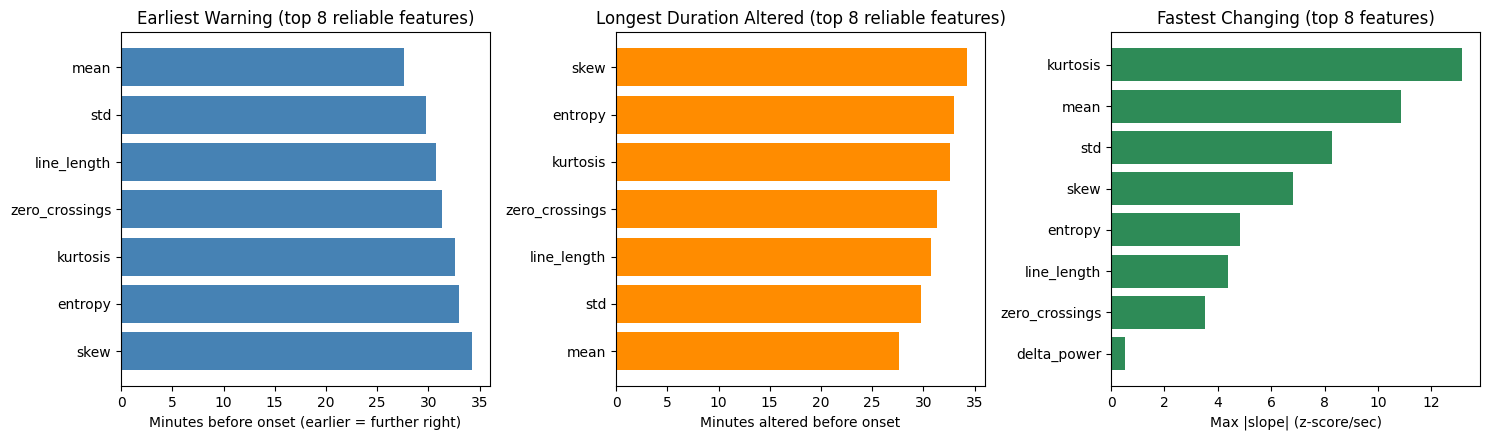

In [40]:
# 4) Feature response-speed comparison bar charts
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

rank_earliest = reliable.sort_values('mean_earliest_onset_min').head(8) if len(reliable) else feature_temporal_summary.head(0)
axes[0].barh(rank_earliest['feature'][::-1], rank_earliest['mean_earliest_onset_min'][::-1].abs(), color='steelblue')
axes[0].set_xlabel('Minutes before onset (earlier = further right)')
axes[0].set_title('Earliest Warning (top 8 reliable features)')

rank_duration = reliable.sort_values('mean_duration_altered_min', ascending=False).head(8) if len(reliable) else feature_temporal_summary.head(0)
axes[1].barh(rank_duration['feature'][::-1], rank_duration['mean_duration_altered_min'][::-1], color='darkorange')
axes[1].set_xlabel('Minutes altered before onset')
axes[1].set_title('Longest Duration Altered (top 8 reliable features)')

rank_speed = feature_temporal_summary.sort_values('mean_max_rate_of_change', ascending=False).head(8)
axes[2].barh(rank_speed['feature'][::-1], rank_speed['mean_max_rate_of_change'][::-1], color='seagreen')
axes[2].set_xlabel('Max |slope| (z-score/sec)')
axes[2].set_title('Fastest Changing (top 8 features)')

plt.tight_layout()
plt.show()


## Step 10: Execution Saving (Pickle)

Every major artifact — feature matrices, trained models, prediction results, feature
importance values, and evaluation metrics, plus the new preictal analysis outputs — is
saved as a `.pkl` file so the full analysis can be reloaded later without repeating
Steps 1-9. Files are written **directly to Google Drive** (not `/content`, which is
wiped on every runtime disconnect) so they persist across sessions.


In [41]:
import pickle

SAVE_DIR = os.path.abspath(os.path.join(DATASET_PATH, '..', 'pipeline_outputs'))
os.makedirs(SAVE_DIR, exist_ok=True)


def save_pickle(obj, name):
    path = os.path.join(SAVE_DIR, f"{name}.pkl")
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    size_kb = os.path.getsize(path) / 1024
    print(f"Saved: {path}  ({size_kb:.1f} KB)")


# 1) Feature matrices (per patient, including the external chb04 test set)
feature_matrices = {
    p: {'flat_X': patient_data[p]['flat_X'], 'seq_X': patient_data[p]['seq_X'],
        'labels': patient_data[p]['labels'], 'feature_names': feature_names}
    for p in PATIENTS
}
if 'ext_flat_X' in globals():
    feature_matrices[EXTERNAL_PATIENT] = {
        'flat_X': ext_flat_X, 'seq_X': ext_seq_X, 'labels': ext_labs, 'feature_names': ext_feat_names
    }
save_pickle(feature_matrices, 'feature_matrices')


Saved: /content/drive/MyDrive/EEG_Dataset/CHB Dataset/pipeline_outputs/feature_matrices.pkl  (36608.0 KB)


In [42]:
# 2) Trained models. Full Keras model objects are not reliably picklable across TF
#    versions, so weights + architecture config are stored instead -- reload by rebuilding
#    the architecture (build_cnn / build_cnn_lstm or Sequential.from_config) and calling
#    model.set_weights(saved['weights']).
def _serialize_model(model):
    return {'weights': model.get_weights(), 'config': model.get_config()}

models_export = {
    'lopo': {
        mt: [{'test_patient': entry['test_patient'], **_serialize_model(entry['model'])}
             for entry in entries]
        for mt, entries in TRAINED_MODELS.items()
    },
    'external': {mt: _serialize_model(m) for mt, m in TRAINED_MODELS_EXTERNAL.items()},
}
save_pickle(models_export, 'trained_models')


Saved: /content/drive/MyDrive/EEG_Dataset/CHB Dataset/pipeline_outputs/trained_models.pkl  (279.0 KB)


In [43]:
# 3) Prediction results (raw per-fold dicts, including stored y_test/y_prob for re-plotting)
predictions_export = {
    'cnn_lopo': cnn_results,
    'cnn_lstm_lopo': cnn_lstm_results,
    'cnn_external': cnn_external,
    'cnn_lstm_external': cnn_lstm_external,
    'feature_count_sweep_summary': feature_count_results,
}
save_pickle(predictions_export, 'prediction_results')

# 4) Feature importance values
feature_importance_export = {
    'importances': importances,
    'feature_rank_table': feature_rank_table,
    'top_feature_order': TOP_FEATURE_ORDER,
}
save_pickle(feature_importance_export, 'feature_importance')

# 5) Evaluation metrics (all summary tables)
evaluation_metrics_export = {
    'cnn_df': cnn_df, 'cnn_lstm_df': cnn_lstm_df, 'comparison_df': comparison_df,
    'meanstd_df': meanstd_df, 'feature_count_df': feature_count_df,
    'timing_df': timing_df, 'timing_summary': timing_summary, 'external_df': external_df,
}
save_pickle(evaluation_metrics_export, 'evaluation_metrics')

# 6) Preictal analysis outputs (Step 9)
preictal_export = {
    'timelines': preictal_timelines,
    'onset_records': onset_records_df,
    'feature_temporal_summary': feature_temporal_summary,
    'effective_window_minutes': matched_window,
}
save_pickle(preictal_export, 'preictal_analysis')

print(f"\nAll artifacts saved to: {SAVE_DIR}")
print("These .pkl files live in Google Drive and will survive future runtime disconnects.")


Saved: /content/drive/MyDrive/EEG_Dataset/CHB Dataset/pipeline_outputs/prediction_results.pkl  (2057.9 KB)
Saved: /content/drive/MyDrive/EEG_Dataset/CHB Dataset/pipeline_outputs/feature_importance.pkl  (3.6 KB)
Saved: /content/drive/MyDrive/EEG_Dataset/CHB Dataset/pipeline_outputs/evaluation_metrics.pkl  (4.0 KB)
Saved: /content/drive/MyDrive/EEG_Dataset/CHB Dataset/pipeline_outputs/preictal_analysis.pkl  (4516.5 KB)

All artifacts saved to: /content/drive/MyDrive/EEG_Dataset/CHB Dataset/pipeline_outputs
These .pkl files live in Google Drive and will survive future runtime disconnects.


**Reloading later, in a fresh session** (after mounting Drive):
```python
import pickle, os
SAVE_DIR = os.path.abspath(os.path.join(DATASET_PATH, '..', 'pipeline_outputs'))
with open(os.path.join(SAVE_DIR, 'evaluation_metrics.pkl'), 'rb') as f:
    evaluation_metrics = pickle.load(f)
# evaluation_metrics['comparison_df'], etc. are ready to use immediately — no need to
# re-run Steps 1-9 just to inspect or re-plot previous results.
```


## Pipeline Complete

Steps 1-7 (data loading & seizure summary, preprocessing, feature extraction with
importance ranking, CNN and CNN-LSTM training under Leave-One-Patient-Out validation,
full metric comparison, a feature-count sweep, and timing comparison), Step 8
(external validation on a genuinely unseen 4th patient, chb04), Step 9 (preictal
feature-timing analysis with deviation-onset detection and feature ranking), and
Step 10 (pickle-based execution saving to Google Drive) have all been executed for
patients **chb01, chb02, chb03** (+ chb04 as the external holdout).


## Suggestions for Further Research-Paper Add-Ons

These are **not implemented above** — they're left as suggestions per your request, so
none of the current results are affected. Listed roughly in order of how much they'd
strengthen a paper relative to the effort involved:

1. **Clarify "detection" vs. "prediction" terminology.** This is the most important one
   to address before writing up results. As built, a segment is labeled positive if it
   *overlaps the seizure itself* — this is technically **seizure detection** (recognizing
   an ongoing seizure), not **seizure prediction** (forecasting a seizure before it
   starts from a pre-ictal window, typically 15-60 minutes prior). A reviewer familiar
   with the seizure-prediction literature will likely flag this distinction. If genuine
   prediction is the goal, labels should instead be built from a defined **pre-ictal
   window** immediately before each seizure's `start_sec` (with a suitable inter-ictal
   negative class), rather than the seizure interval itself.

2. **Ablation study by feature category.** Re-run Step 6-style comparisons using only
   time-domain features, only frequency-band features, and only entropy, to report which
   *category* (not just which top-K count) drives performance — a natural companion to
   the Random Forest ranking already computed.

3. **Statistical significance testing**, e.g. a paired test (Wilcoxon signed-rank or
   paired t-test) comparing CNN vs. CNN-LSTM fold-level F1/AUC scores. Worth explicitly
   noting as a limitation that with only 3 LOPO folds, such a test is underpowered —
   this is more meaningful once more patients are added.

4. **Data/class-imbalance handling beyond class weighting** — e.g. SMOTE on the feature
   vectors, or focal loss instead of binary cross-entropy — with a comparison against
   the current class-weighted baseline.

5. **Model interpretability beyond Random Forest importances** — e.g. SHAP values or
   permutation importance computed directly on the trained CNN, to connect the
   deep-learning results back to interpretable EEG features (useful for a
   clinically-oriented paper).

6. **Batch inference throughput**, alongside the existing per-segment latency in Step 7
   — e.g. segments/second at realistic batch sizes — relevant if positioning either
   model for real-time deployment.

7. **Explicit dataset characteristics table** — sampling rate, number of channels,
   recording duration per patient, seizure/non-seizure class ratio — often expected in a
   paper's Dataset subsection; most of these values are already available in
   `seg_summary` and `patient_data` above and just need collecting into one table.

